# Demand Forecasting (Amazon Sales)

Цель проекта — прогноз спроса на товары по категориям на следующий месяц
на основе исторических данных о продажах.

В ноутбуке представлены:
- регрессионные модели
- модели классификации для предсказания спада спроса
- анализ факторов спроса
- модели временных рядов (SARIMA)


## 1. Загрузка и обзор данных


### Почему мы выбрали Amazon?

Amazon — одна из крупнейших и самых известных платформ электронной коммерции в мире, с оборотом более 500 млрд $.  
Она предоставляет огромное количество разнообразных данных о покупках, что делает её идеальным объектом для анализа и прогнозирования.  

Работа с реальными данными Amazon позволяет нам применить современные методы машинного обучения к практической бизнес-задаче, актуальной для любой компании в сфере ритейла и логистики.

---

## Бизнес-проблема

**Как предсказать спрос (количество покупок) на товары по категориям, чтобы оптимизировать запасы и избежать дефицита или перепроизводства?**

Неправильное планирование запасов ведёт к потерям: либо из-за нехватки товаров, либо из-за излишков, что увеличивает издержки и снижает прибыль.

---

## Цель проекта

Мы планируем построить модель, которая сможет прогнозировать спрос на товары по категориям на **следующий месяц**, используя исторические данные о продажах Amazon (чеки и заказы).

Такой прогноз поможет бизнесу принимать более обоснованные решения по управлению запасами и улучшить эффективность логистики.




###**Датасеты:**
Мы отобрали следующий датасет
https://www.kaggle.com/datasets/anandshaw2001/amazon-sales-dataset

### Почему мы выбрали этот датасет?

- Данный датасет содержит данные по продажам Amazon, включающие ключевые параметры, такие как даты заказов и отправки, географию покупателей, категории и названия продуктов, количество проданных единиц, сумму продаж и прибыль.

- Этот набор данных позволяет всесторонне проанализировать поведение покупателей и динамику продаж, что критически важно для решения задачи прогнозирования спроса.

- Кроме того, датасет достаточно объемный (3204 строки), что обеспечивает достаточную статистическую основу для построения и валидации моделей машинного обучения.

## Примечание по данным

- Данный датасет вероятнее всего содержит информацию, приближенную к реальным данным о продажах на платформе Amazon, так как в ней раскрываются персональные данные. Однако, учитывая отсутствие официального подтверждения и возможные ограничения конфиденциальности, можно считать, что данные являются либо агрегированными, либо сгенерированными на основе реальных шаблонов поведения покупателей и продаж.  

- Это означает, что несмотря на высокую степень реалистичности, в данных **могут отсутствовать некоторые нюансы и аномалии, характерные для настоящих бизнес-операций**.  

- Тем не менее, мы считаем этот датасет достаточно достоверным для анализа

### Описание столбцов (Column Description)

- **Order Date** — дата оформления заказа (Order_Date)  
- **Ship Date** — дата отправки заказа (Shipping Date)  
- **Email_ID** — электронная почта пользователя (Email_ID of Users)  
- **Geography** — географическое расположение заказов (Location of Orders by Users)  
- **Category** — категория продукта (Product Category)  
- **Product Name** — название продукта на Amazon (Product Name of Amazon)  
- **Sales** — сумма продаж продукта на Amazon (Amazon Product Sales)  
- **Quantity** — количество единиц конкретного продукта в заказе (how many units of a particular product are available)  
- **Profit** — прибыль с продаж продукта на Amazon (Amazon Sales Profit)


In [ ]:
#Загрузка библиотек
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import _tree
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [ ]:
#загрузка основного датфрейма
df=pd.read_excel('/content/Amazon 2_Raw.xlsx')

In [ ]:
display("First 5 records:", df.head())

'First 5 records:'

,Order ID,Order Date,Ship Date,EmailID,Geography,Category,Product Name,Sales,Quantity,Profit
0,CA-2013-138688,2013-06-13,2013-06-17,DarrinVanHuff@gmail.com,"United States,Los Angeles,California",Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,6.8714
1,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7,14.1694
2,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Art,Newell 322,7.280,4,1.9656
3,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Phones,Mitel 5320 IP Phone VoIP phone,907.152,4,90.7152
4,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Binders,DXL Angle-View Binders with Locking Rings by S...,18.504,3,5.7825


In [ ]:
# Общая информация о типах данных
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3203 entries, 0 to 3202
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order ID      3203 non-null   object        
 1   Order Date    3203 non-null   datetime64[ns]
 2   Ship Date     3203 non-null   datetime64[ns]
 3   EmailID       3203 non-null   object        
 4   Geography     3203 non-null   object        
 5   Category      3203 non-null   object        
 6   Product Name  3203 non-null   object        
 7   Sales         3203 non-null   float64       
 8   Quantity      3203 non-null   int64         
 9   Profit        3203 non-null   float64       
dtypes: datetime64[ns](2), float64(2), int64(1), object(5)
memory usage: 250.4+ KB


Все типы отображаются корректно, но на всякий случай поработаем с datetime

In [ ]:
import re
from collections import Counter
import nltk
from nltk.corpus import stopwords

# Скачиваем стоп-слова (один раз) из специальной библиотеки
nltk.download('stopwords')
#Настраиваем английские слова-связки
stop_words = set(stopwords.words('english'))

# Берём все названия товаров, объединяем в один большой текст и переводим в нижний регистр
all_text = ' '.join(df['Product Name'].dropna()).lower()

# Разбиваем текст на отдельные слова (только буквы и цифры)
words = re.findall(r'\b\w+\b', all_text)

# Убираем стоп-слова и числа
filtered_words = [w for w in words if w not in stop_words and not w.isdigit()]

# Считаем, сколько раз каждое слово встречается
word_counts = Counter(filtered_words)

# Создаём таблицу с 20 самыми частыми словами
word_freq_df = pd.DataFrame(word_counts.most_common(10), columns=['Word', 'Frequency'])

display(word_freq_df)




[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Word,Frequency
0,xerox,289
1,x,219
2,avery,172
3,chair,164
4,binders,159
5,black,144
6,phone,127
7,binder,118
8,ring,116
9,file,114


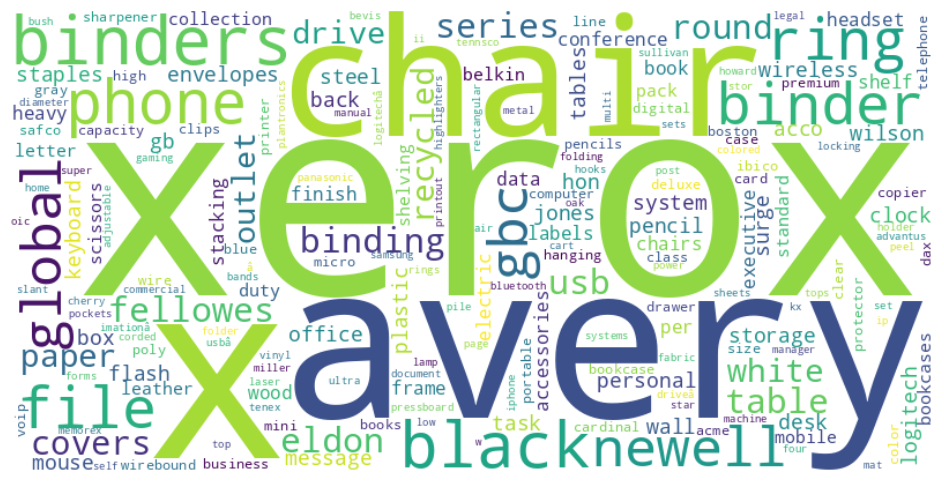

In [ ]:
#Построим облако слов
from wordcloud import WordCloud

wc = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_counts)
plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()


Видим известные компании - их можно извлечь - вручную отбираем самые частые копмании

In [ ]:
import re

companies = [
    'xerox', 'avery', 'newell', 'gbc', 'eldon',
    'fellowes', 'acco', 'hon', 'staples', 'wilson'
]

def find_company(product_name):
    product_name_lower = product_name.lower()
    for comp in companies:
        # паттерн с границами слова(чтобы не было случаев, когда phone становится hon)
        pattern = r'\b' + re.escape(comp) + r'\b'
        if re.search(pattern, product_name_lower):
            return comp
    return 'others'

df['Manufacturer'] = df['Product Name'].apply(find_company)
df.head()

,Order ID,Order Date,Ship Date,EmailID,Geography,Category,Product Name,Sales,Quantity,Profit,Manufacturer
0,CA-2013-138688,2013-06-13,2013-06-17,DarrinVanHuff@gmail.com,"United States,Los Angeles,California",Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,6.8714,others
1,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7,14.1694,eldon
2,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Art,Newell 322,7.280,4,1.9656,newell
3,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Phones,Mitel 5320 IP Phone VoIP phone,907.152,4,90.7152,others
4,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Binders,DXL Angle-View Binders with Locking Rings by S...,18.504,3,5.7825,others


In [ ]:
# Преобразуем даты в формат datetime (на всякий случай)
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [ ]:
# Кол-во пропусков по столбцам
df.isnull().sum()

,0
Order ID,0
Order Date,0
Ship Date,0
EmailID,0
Geography,0
Category,0
Product Name,0
Sales,0
Quantity,0
Profit,0


In [ ]:
#Описательная статистика по всем колонкам
df.describe(include='all')

,Order ID,Order Date,Ship Date,EmailID,Geography,Category,Product Name,Sales,Quantity,Profit,Manufacturer
count,3203,3203,3203,3203,3203,3203,3203,3203.000000,3203.000000,3203.000000,3203
unique,1611,NaN,NaN,686,170,17,1494,NaN,NaN,NaN,11
top,CA-2013-165330,NaN,NaN,WilliamBrown@gmail.com,"United States,Los Angeles,California",Binders,Staples,NaN,NaN,NaN,others
freq,11,NaN,NaN,24,747,471,60,NaN,NaN,NaN,2132
mean,NaN,2013-05-10 03:06:07.530440192,2013-05-14 01:25:25.195129600,NaN,NaN,NaN,NaN,226.493233,3.828910,33.849032,NaN
min,NaN,2011-01-07 00:00:00,2011-01-09 00:00:00,NaN,NaN,NaN,NaN,0.990000,1.000000,-3399.980000,NaN
25%,NaN,2012-05-22 00:00:00,2012-05-26 00:00:00,NaN,NaN,NaN,NaN,19.440000,2.000000,3.852000,NaN
50%,NaN,2013-07-22 00:00:00,2013-07-25 00:00:00,NaN,NaN,NaN,NaN,60.840000,3.000000,11.166400,NaN
75%,NaN,2014-05-23 00:00:00,2014-05-27 00:00:00,NaN,NaN,NaN,NaN,215.809000,5.000000,33.000400,NaN
max,NaN,2014-12-31 00:00:00,2015-01-06 00:00:00,NaN,NaN,NaN,NaN,13999.960000,14.000000,6719.980800,NaN


In [ ]:
#проверка на дубли
df.duplicated().sum()

np.int64(0)

In [ ]:
# Частота встречаемости категорий

# Подсчёт количества по категориям
category_counts = df['Category'].value_counts().reset_index()
category_counts.columns = ['Category', 'Count']

# Построение бар-чарта
fig = px.bar(category_counts,
             x='Category',
             y='Count',
             title='Частота заказов по категориям',
             labels={'Count': 'Количество заказов', 'Category': 'Категория'},
             color='Count',
             color_continuous_scale='Viridis')

fig.update_layout(xaxis_tickangle=-45)
fig.show()


In [ ]:
# Распределение по географии
df['Geography'].value_counts().head()

,count
Geography,
"United States,Los Angeles,California",747
"United States,San Francisco,California",510
"United States,Seattle,Washington",428
"United States,San Diego,California",170
"United States,Phoenix,Arizona",63


In [ ]:
# Разделим колонку Geography на 3 части
df[['Country', 'City', 'State']] = df['Geography'].str.split(',', expand=True)

# Проверим результат
df[['Geography', 'Country', 'City', 'State']].describe(include='all')


,Geography,Country,City,State
count,3203,3203,3203,3203
unique,170,1,169,11
top,"United States,Los Angeles,California",United States,Los Angeles,California
freq,747,3203,747,2001


In [ ]:
# Частота встречаемости штатов

# Подсчёт количества по штатам
state_counts = df['State'].value_counts().reset_index()
state_counts.columns = ['State', 'Count']

# Построение бар-чарта
fig = px.bar(state_counts,
             x='State',
             y='Count',
             title='Частота заказов по категориям',
             labels={'Count': 'Количество заказов', 'State': 'Штат'},
             color='Count',
             color_continuous_scale='Viridis')

fig.update_layout(xaxis_tickangle=-45)
fig.show()

In [ ]:
!pip install us

In [ ]:
import us

# Функция для преобразования полного названия штата в сокращение
def get_state_abbr(name):
    state = us.states.lookup(name)
    return state.abbr if state else None

# Создаем новый столбец с сокращениями
df['StateCode'] = df['State'].apply(get_state_abbr)

# Проверим
print(df[['State', 'StateCode']].drop_duplicates())


           State StateCode
0     California        CA
8     Washington        WA
9           Utah        UT
21       Arizona        AZ
28        Oregon        OR
30      Colorado        CO
57    New Mexico        NM
112       Nevada        NV
161      Montana        MT
985        Idaho        ID
1907     Wyoming        WY


In [ ]:
import plotly.express as px

# Группируем по штатам, считаем суммарные продажи
state_sales = df.groupby('StateCode')['Order ID'].count().reset_index()

# Строим карту
fig = px.choropleth(state_sales,
                    locations='StateCode',
                    locationmode="USA-states",
                    color='Order ID',
                    color_continuous_scale="Viridis",
                    scope="usa",
                    labels={'Order ID':'Суммарные кол-во заказов'},
                    title='Суммарные заказы по штатам США')

fig.show()


Видим, что все данные по США, поэтому можем удалить колонки Geography и Country

Более того видим, что большинство заказов из западной части США, а именно большинство из Калифорнии и Вашингтона

In [ ]:
import plotly.graph_objects as go

category_sales = df.groupby('Category')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)

fig = go.Figure()

fig.add_trace(go.Bar(
    x=category_sales.index,
    y=category_sales['Sales'],
    name='Sales',
    marker_color='rgba(100, 149, 237, 0.6)'  # мягкий голубой (cornflowerblue) с прозрачностью
))

fig.add_trace(go.Bar(
    x=category_sales.index,
    y=category_sales['Profit'],
    name='Profit',
    marker_color='rgba(60, 179, 113, 0.6)'  # мягкий зелёный (mediumseagreen) с прозрачностью
))

fig.update_layout(
    title='Продажи и прибыль по категориям',
    xaxis_title='Категория',
    yaxis_title='Сумма',
    barmode='group',
    xaxis_tickangle=-45, #угол наклона подписей
    template='plotly_white',
    height=500,
    width=800
)

fig.show()


In [ ]:
# Извлекаем новые признаки из даты
df['OrderMonth'] = df['Order Date'].dt.month  # месяц заказа
df['OrderWeekday'] = df['Order Date'].dt.weekday  # день недели
df['ShippingDays'] = (df['Ship Date'] - df['Order Date']).dt.days  # сколько дней заняла доставка
df['OrderYear'] = df['Order Date'].dt.year


In [ ]:
# Добавляем обобщённую категорию товаров (ProductGroup)
df['ProductGroup'] = df['Category'].replace({
    'Binders': 'Office', 'Labels': 'Office', 'Furnishings': 'Furniture',
    'Chairs': 'Furniture', 'Phones': 'Technology', 'Paper': 'Office',
    'Art': 'Leisure', 'Storage': 'Furniture', 'Accessories': 'Leisure',
    'Tables': 'Furniture', 'Envelopes': 'Office', 'Bookcases': 'Furniture',
    'Fasteners': 'Office', 'Supplies': 'Office', 'Appliances': 'Technology',
    'Machines': 'Technology', 'Copiers': 'Technology'
})

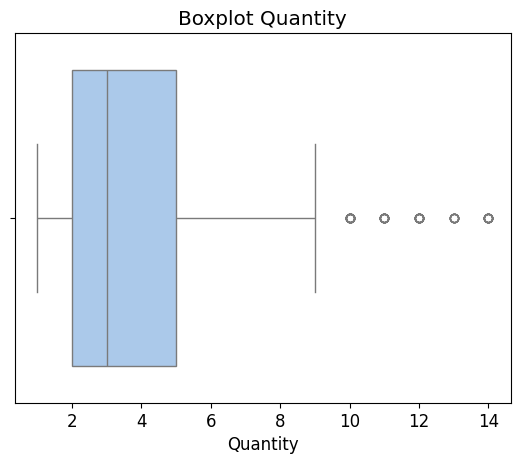

Q1 (25-й перцентиль): 2.00
Q3 (75-й перцентиль): 5.00
IQR (межквартильный размах): 3.00
Нижняя граница выбросов: -2.50
Верхняя граница выбросов: 9.50


In [ ]:
# Boxplot Quantity
sns.boxplot(x=df['Quantity'])
plt.title('Boxplot Quantity')
plt.xlabel('Quantity')
plt.show()

# Расчет межквартильного размаха
Q1 = df['Quantity'].quantile(0.25)
Q3 = df['Quantity'].quantile(0.75)
IQR = Q3 - Q1

# Границы выбросов
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 (25-й перцентиль): {Q1:.2f}")
print(f"Q3 (75-й перцентиль): {Q3:.2f}")
print(f"IQR (межквартильный размах): {IQR:.2f}")
print(f"Нижняя граница выбросов: {lower_bound:.2f}")
print(f"Верхняя граница выбросов: {upper_bound:.2f}")



In [ ]:
# Кол-во строк всего
total = len(df)

# Кол-во выбросов уже найдено ранее
outliers = df[(df['Quantity'] < lower_bound) | (df['Quantity'] > upper_bound)]
outlier_count = len(outliers)

# Процент выбросов
outlier_percentage = (outlier_count / total) * 100

print(f"Процент выбросов: {outlier_percentage:.2f}%")


Процент выбросов: 1.94%


In [ ]:
# Удаляем выбросы из df
df = df[(df['Quantity'] >= lower_bound) & (df['Quantity'] <= upper_bound)]

# Проверяем, сколько строк осталось
print(f"Количество строк после удаления выбросов: {len(df)}")


Количество строк после удаления выбросов: 3141


Text(0.5, 0, 'Дней')

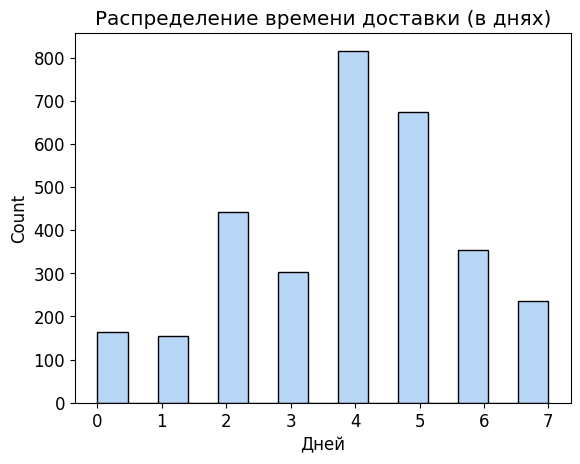

In [ ]:
sns.histplot(df['ShippingDays'], bins=15)
plt.title('Распределение времени доставки (в днях)')
plt.xlabel('Дней')

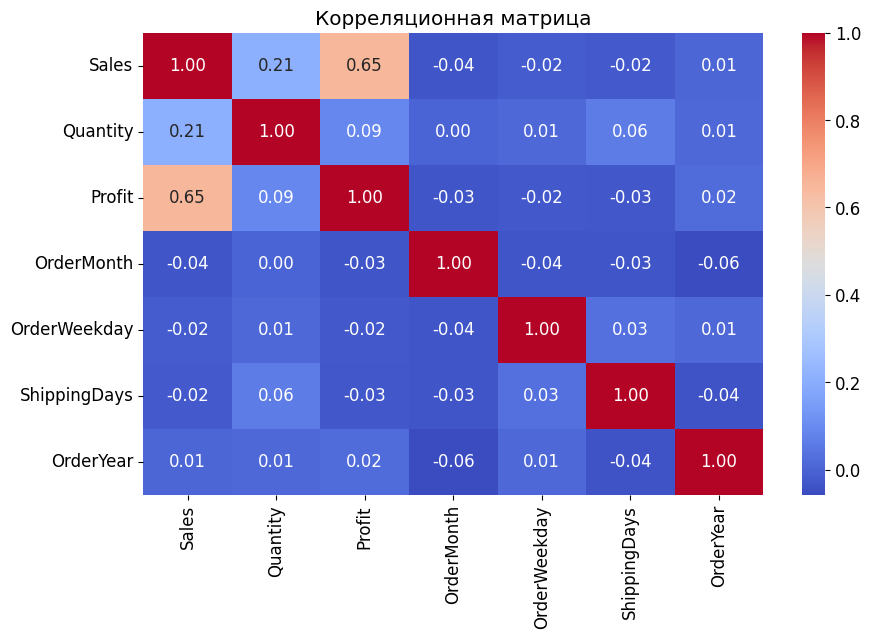

In [ ]:
# Корреляционная матрица по числовым признакам
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Корреляционная матрица')
plt.show()


- Sales и Profit — сильно коррелируют, коэффициент корреляции 0.65, возможна коллинеарность
- Quantity также коррелирует с Sales, но коэффициент корреляции невысокий - 0.21

In [ ]:
df.head()

,Order ID,Order Date,Ship Date,EmailID,Geography,Category,Product Name,Sales,Quantity,Profit,Manufacturer,Country,City,State,StateCode,OrderMonth,OrderWeekday,ShippingDays,OrderYear,ProductGroup
0,CA-2013-138688,2013-06-13,2013-06-17,DarrinVanHuff@gmail.com,"United States,Los Angeles,California",Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,6.8714,others,United States,Los Angeles,California,CA,6,3,4,2013,Office
1,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7,14.1694,eldon,United States,Los Angeles,California,CA,6,3,5,2011,Furniture
2,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Art,Newell 322,7.280,4,1.9656,newell,United States,Los Angeles,California,CA,6,3,5,2011,Leisure
3,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Phones,Mitel 5320 IP Phone VoIP phone,907.152,4,90.7152,others,United States,Los Angeles,California,CA,6,3,5,2011,Technology
4,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Binders,DXL Angle-View Binders with Locking Rings by S...,18.504,3,5.7825,others,United States,Los Angeles,California,CA,6,3,5,2011,Office


In [ ]:
# Удаляем лишние столбцы
df = df.drop(columns=['Order ID','EmailID','Geography', 'Country','Product Name','Ship Date'])

### подпроблема 1

**1. Прогнозирование спроса на товары**

*Проблема:* Предсказать, сколько единиц товара (Quantity) купят в следующем месяце по категориям (Category).

*Фичи:*

Исторические продажи (агрегация по Order Date и Category).

Лаги продаж (например, продажи за прошлый месяц).

Признаки времени (month, day_of_week, is_holiday).

**Подпроблема** **1**: **Прогноз** **количества** **покупок**

***Цель***: построить модель для прогнозирования количества продаж по категориям товаров на следующий месяц на основе исторических данных

Подготовка данных, создание и кодирование признаков

In [ ]:
monthly_data = df.groupby(['Category', 'OrderYear', 'OrderMonth'])['Quantity'].sum().reset_index()

# Сортируем по категории и дате
monthly_data = monthly_data.sort_values(['Category', 'OrderYear', 'OrderMonth'])

# Добавляем продажи за предыдущие месяцы
for i in range(1, 4):
    monthly_data[f'Lag_{i}'] = monthly_data.groupby('Category')['Quantity'].shift(i)

#продажи за тот же месяц, но 12 месяцев назад
monthly_data['Lag_12'] = monthly_data.groupby('Category')['Quantity'].shift(12)

# Удаляем строки с пропусками

monthly_data = monthly_data.dropna()
#преобразуем категории в числовой формат

categories = monthly_data['Category'].unique()
category_mapping = {category: i+1 for i, category in enumerate(categories)}

# Применяем преобразование
monthly_data['Category_encoded'] = monthly_data['Category'].replace(category_mapping)

/tmp/ipython-input-432-3485419648.py:22: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



In [ ]:
#данные должны быть отсортированы по дате
monthly_data = monthly_data.sort_values(['OrderYear', 'OrderMonth'])

features = ['Lag_1', 'Lag_2', 'Lag_3', 'Lag_12', 'Category_encoded']
X = monthly_data[features]
y = monthly_data['Quantity']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False,  # Сохраняем хронологический порядок
    random_state=42  # Для воспроизводимости
)


Обучение модели

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

Метрики

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, max_error

print("MSE: ", mean_squared_error(y_test, y_pred))
print("MAE: ", mean_absolute_error(y_test, y_pred))
print("MAX_ERROR: ", max_error(y_test, y_pred))
print("RMSE: ", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² (объясненная дисперсия):", model.score(X_test, y_test))

MSE:  199.7200713075172
MAE:  9.66467150090054
MAX_ERROR:  60.871891717253064
RMSE:  14.13223518441146
R² (объясненная дисперсия): 0.6201798301944589


Модель линейной регрессии демонстрирует умеренную производительность.


*   R² = 0.633 - Модель объясняет около 63% дисперсии данных. Это приемлемо, но есть пространство для улучшения.
*   RMSE = 15.21 - Средняя ошибка прогноза составляет около 15 единиц товара.
*  MAE = 10.73 - Средняя абсолютная ошибка около 11 единиц.
*  Max Error = 59.17 - Наибольшая ошибка в прогнозе составила ~59 единиц.



Text(0, 0.5, 'Количество продаж')

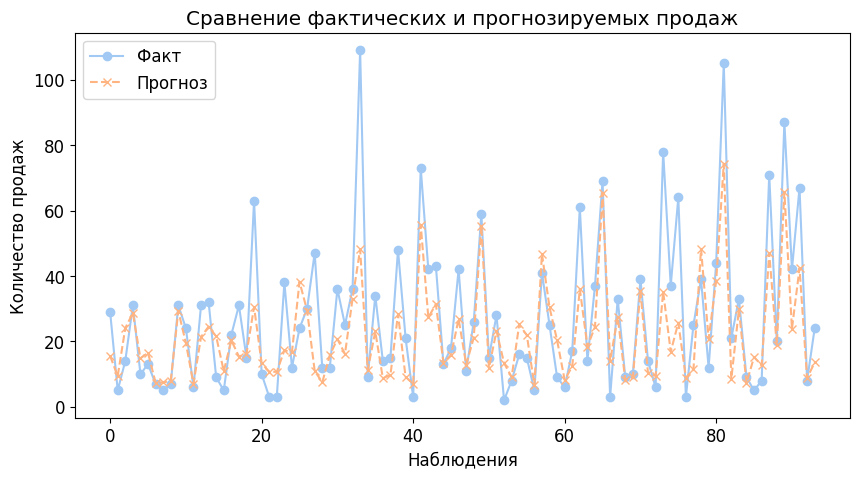

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label='Факт', marker='o')
plt.plot(y_pred, label='Прогноз', linestyle='--', marker='x')
plt.legend()
plt.title('Сравнение фактических и прогнозируемых продаж')
plt.xlabel('Наблюдения')
plt.ylabel('Количество продаж')

In [ ]:
y_pred_baseline=y_pred

Добавим улучшения

In [ ]:
# Преобразование даты
# Агрегация по месяцам и категориям
monthly_data = df.groupby(['Category', 'OrderYear', 'OrderMonth'])['Quantity'].sum().reset_index()
monthly_data = monthly_data.sort_values(['Category', 'OrderYear', 'OrderMonth'])

In [ ]:
# Добавление лагов за 1, 2, 3 и 12 месяцев
for lag in [1, 2, 3, 12]:
    monthly_data[f'Lag_{lag}'] = monthly_data.groupby('Category')['Quantity'].shift(lag)

# Удаление строк с пропусками (где нет всех лагов)
monthly_data = monthly_data.dropna()

**Добавление средних и медианных значений**


*   Category_Avg – средние продажи по каждой категории (помогает учесть разницу в масштабах между категориями).
*   Month_Avg – медианные продажи по каждому месяцу (учитывает сезонность).


Это помогает модели понимать базовый уровень продаж для каждой категории и месяца.

**Трендовый признак**


*   Trend = groupby('Category').cumcount() – номер месяца для каждой категории (позволяет модели учитывать долгосрочный тренд)


**Относительные признаки**
*   Lag_1_Ratio = Lag_1 / Category_Avg – показывает, насколько прошлые продажи отклоняются от среднего уровня.


Это помогает модели нормализовать данные и лучше интерпретировать лаги.

In [ ]:
# Средние и медианные значения
monthly_data['Category_Avg'] = monthly_data.groupby('Category')['Quantity'].transform('mean')
monthly_data['Month_Avg'] = monthly_data.groupby('OrderMonth')['Quantity'].transform('median')

# Тренд и относительные признаки
monthly_data['Trend'] = monthly_data.groupby('Category').cumcount()  # Номер месяца для каждой категории
monthly_data['Lag_1_Ratio'] = monthly_data['Lag_1'] / monthly_data['Category_Avg']  # Отношение лага к среднему

/tmp/ipython-input-440-3097562639.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipython-input-440-3097562639.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipython-input-440-3097562639.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipyth

Text(0.5, 1.0, 'Корреляция добавленных признаков')

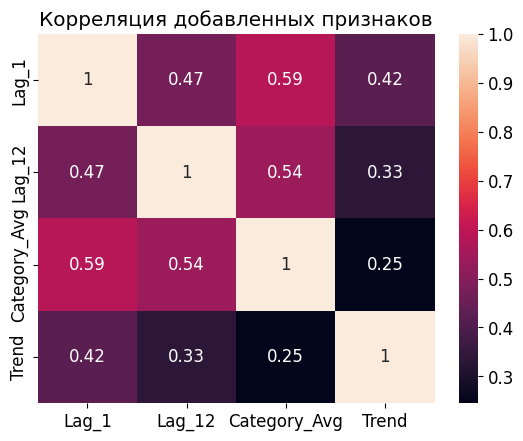

In [ ]:
sns.heatmap(monthly_data[['Lag_1', 'Lag_12', 'Category_Avg', 'Trend']].corr(), annot=True)
plt.title('Корреляция добавленных признаков')

Проблемы мультиколлинеарности

Нет критических значений (все корреляции <0.7

Признаки	Корреляция	Интерпретация

Lag_1 и Category_Avg	0.55	Умеренная связь. Значит, средние продажи по категории частично объясняют последние продажи.

Lag_12 и Category_Avg	0.46	Слабая-умеренная связь. Годовой лаг содержит дополнительную информацию.

Trend и Lag_1	0.37	Слабая связь. Тренд слабо связан с недавними продажами.

**Удаление экстремальных значений**

*   Отфильтровываем 5% самых низких и 5% самых высоких значений (quantile(0.05) и quantile(0.95)).


Это уменьшает влияние выбросов, которые могли искажать предсказания.

In [ ]:
# Удаление экстремальных значений (5% снизу и сверху)
Q1 = monthly_data['Quantity'].quantile(0.05)
Q3 = monthly_data['Quantity'].quantile(0.95)
monthly_data = monthly_data[(monthly_data['Quantity'] >= Q1) & (monthly_data['Quantity'] <= Q3)]

In [ ]:
# Выбор финальных признаков
features = ['Lag_1', 'Lag_2', 'Lag_3', 'Lag_12', 'Category_Avg', 'Month_Avg', 'Trend', 'Lag_1_Ratio']
X = monthly_data[features]
y = monthly_data['Quantity']

# Разделение на train/test (без перемешивания!)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


Масштабирование признаков

In [ ]:
# Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Обучение модели

In [ ]:
# 9. Обучение модели
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# 10. Прогнозирование и оценка
y_pred = model.predict(X_test_scaled)

# 11. Вычисление метрик
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("=== Метрики модели ===")
print(f"MSE: {mse:.2f}")      # Среднеквадратичная ошибка
print(f"MAE: {mae:.2f}")      # Средняя абсолютная ошибка
print(f"RMSE: {rmse:.2f}")    # Корень из MSE
print(f"R²: {r2:.4f}")        # Коэффициент детерминации

=== Метрики модели ===
MSE: 77.44
MAE: 6.67
RMSE: 8.80
R²: 0.4640


In [ ]:
y_pred_improved=y_pred

Text(0, 0.5, 'Количество продаж')

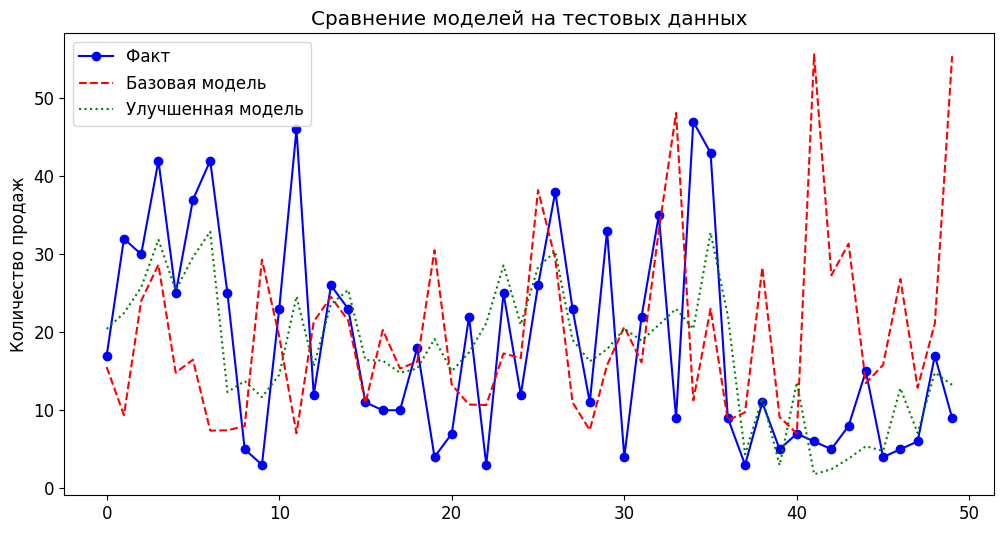

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.values[:50], label='Факт', marker='o', color='blue')  # Первые 50 точек для наглядности
plt.plot(y_pred_baseline[:50], label='Базовая модель', linestyle='--', color='red')
plt.plot(y_pred_improved[:50], label='Улучшенная модель', linestyle=':', color='green')
plt.legend()
plt.title('Сравнение моделей на тестовых данных')
plt.ylabel('Количество продаж')

MSE, MAE, RMSE значительно снизились

Ошибки уменьшились, значит, модель стала точнее предсказывать.



*   Особенно сильно упал MSE (на 57%), что говорит о том, что модель теперь делает меньше крупных ошибок.
*   R² ухудшился (с 0.63 до 0.43)

Это может означать, что:

Мы удалили часть вариативности данных (из-за отсечения выбросов).

Новые признаки (средние, тренды) не полностью объясняют целевую переменную.

Модель стала более консервативной (меньше переобучается, но и хуже объясняет дисперсию).



---



## (Карина) подпроблема 2: упадет ли спрос

### Подготовка данных

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1738 entries, 59 to 3199
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Order Date         1738 non-null   datetime64[ns]
 1   Category           1738 non-null   object        
 2   Sales              1738 non-null   float64       
 3   Quantity           1738 non-null   int64         
 4   Profit             1738 non-null   float64       
 5   Manufacturer       1738 non-null   object        
 6   City               1738 non-null   object        
 7   State              1738 non-null   object        
 8   StateCode          1738 non-null   object        
 9   OrderMonth         1738 non-null   int32         
 10  OrderWeekday       1738 non-null   int32         
 11  ShippingDays       1738 non-null   int64         
 12  OrderYear          1738 non-null   int32         
 13  ProductGroup       1738 non-null   object        
 14  NextMonthQua

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Фиксируем random seed
np.random.seed(42)

# 2. Подготовка данных
def prepare_data(df):
    df['NextMonthQuantity'] = df.groupby(['Category', 'City', 'OrderYear', 'OrderMonth'])['Quantity'].shift(-1)
    df['Demand_Drop'] = (df['NextMonthQuantity'] < df['Quantity'] * 0.75).astype(int)
    df['PricePerUnit'] = df['Sales'] / df['Quantity']
    df['IsWeekend'] = (df['OrderWeekday'] >= 5).astype(int)  # 5-суббота, 6-воскресенье

    for lag in [1, 2, 3, 6, 12]:
        df[f'Quantity_Lag_{lag}'] = df.groupby(['Category', 'City'])['Quantity'].shift(lag)

    for window in [3, 6]:
        df[f'Rolling_Avg_{window}'] = df.groupby(['Category', 'City'])['Quantity'].transform(
            lambda x: x.rolling(window, min_periods=1).mean()
        )
        df[f'Rolling_Std_{window}'] = df.groupby(['Category', 'City'])['Quantity'].transform(
            lambda x: x.rolling(window, min_periods=1).std()
        )

    df['MoM_Growth'] = df.groupby(['Category', 'City'])['Quantity'].pct_change(1)
    df['YoY_Growth'] = df.groupby(['Category', 'City'])['Quantity'].pct_change(12)

    return df.dropna(subset=['Demand_Drop', 'Quantity_Lag_1', 'Quantity_Lag_2', 'Quantity_Lag_3'])

# 3. Разделение данных
def time_split(df, test_size=0.2):
    df = df.sort_values(['OrderYear', 'OrderMonth', 'Category', 'City'])
    split_idx = int(len(df) * (1 - test_size))
    return df.iloc[:split_idx], df.iloc[split_idx:]

# 4. Подготовка финальных данных
def get_features(train_df, test_df):
    cat_cols = ['Category', 'City', 'State', 'ProductGroup']
    num_cols = [
        'Quantity_Lag_1', 'Quantity_Lag_2', 'Quantity_Lag_3',
        'Quantity_Lag_6', 'Quantity_Lag_12',
        'PricePerUnit', 'Profit', 'OrderMonth', 'OrderWeekday', 'IsWeekend',
        'Rolling_Avg_3', 'Rolling_Std_3', 'Rolling_Avg_6', 'Rolling_Std_6',
        'MoM_Growth', 'YoY_Growth'
    ]

    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    encoder.fit(train_df[cat_cols])

    def prepare_X(df):
        return np.hstack([df[num_cols], encoder.transform(df[cat_cols])])

    return (
        prepare_X(train_df),
        prepare_X(test_df),
        train_df['Demand_Drop'],
        test_df['Demand_Drop'],
        num_cols,
        cat_cols
    )

# Основной пайплайн
df = prepare_data(df)
train_df, test_df = time_split(df)
X_train, X_test, y_train, y_test, num_cols, cat_cols = get_features(train_df, test_df)

# Проверка
print(f"Train periods: {train_df['OrderYear'].min()}-{train_df['OrderMonth'].min()} to "
      f"{train_df['OrderYear'].max()}-{train_df['OrderMonth'].max()}")
print(f"Test periods: {test_df['OrderYear'].min()}-{test_df['OrderMonth'].min()} to "
      f"{test_df['OrderYear'].max()}-{test_df['OrderMonth'].max()}")
print(f"\nTrain shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Train balance: {y_train.mean():.2%} спадов")
print(f"Test balance: {y_test.mean():.2%} спадов")






Train periods: 2011-1 to 2014-12
Test periods: 2014-7 to 2014-12

Train shape: (1390, 71), Test shape: (348, 71)
Train balance: 13.02% спадов
Test balance: 14.94% спадов


### randomforest

In [ ]:
# Модель 1: RandomForest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=7,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
print("\nRandomForest Report:")
print(classification_report(y_test, rf.predict(X_test)))


RandomForest Report:
              precision    recall  f1-score   support

           0       0.88      0.89      0.88       296
           1       0.31      0.29      0.30        52

    accuracy                           0.80       348
   macro avg       0.59      0.59      0.59       348
weighted avg       0.79      0.80      0.79       348



### balancedrandomforestclassifier

In [ ]:
!pip install imbalanced-learn

In [ ]:
# Модель 2: BalancedRandomForest

brf = BalancedRandomForestClassifier(
    n_estimators=200,
    max_depth=7,
    sampling_strategy='auto',
    replacement=True,
    random_state=42,
    n_jobs=-1
)
brf.fit(X_train, y_train)
print("\nBalancedRandomForest Report:")
print(classification_report(y_test, brf.predict(X_test)))



BalancedRandomForest Report:
              precision    recall  f1-score   support

           0       0.92      0.64      0.75       296
           1       0.25      0.69      0.37        52

    accuracy                           0.64       348
   macro avg       0.59      0.66      0.56       348
weighted avg       0.82      0.64      0.69       348



### catboost

In [ ]:
!pip install catboost

In [ ]:
# Модель 3: CatBoost
catboost = CatBoostClassifier(
    iterations=500,
    learning_rate=0.03,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    eval_metric='F1',
    early_stopping_rounds=50,
    random_state=42,
    verbose=100
)
catboost.fit(
    train_df[num_cols + cat_cols], y_train,
    cat_features=cat_cols,
    eval_set=(test_df[num_cols + cat_cols], y_test)
)
print("\nCatBoost Report:")
print(classification_report(y_test, catboost.predict(test_df[num_cols + cat_cols])))

0:	learn: 0.6525253	test: 0.6775170	best: 0.6775170 (0)	total: 3.66ms	remaining: 1.83s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7366159441
bestIteration = 12

Shrink model to first 13 iterations.

CatBoost Report:
              precision    recall  f1-score   support

           0       0.94      0.70      0.80       296
           1       0.30      0.73      0.43        52

    accuracy                           0.71       348
   macro avg       0.62      0.72      0.62       348
weighted avg       0.84      0.71      0.75       348



### visualizations

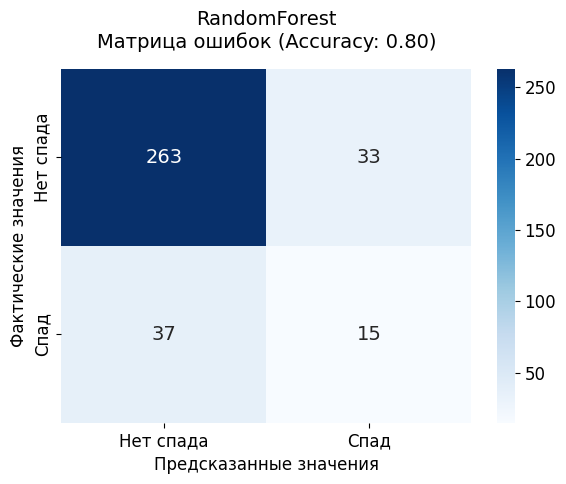

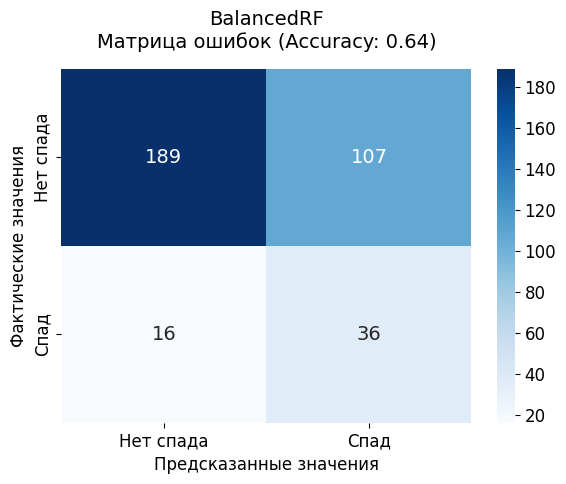

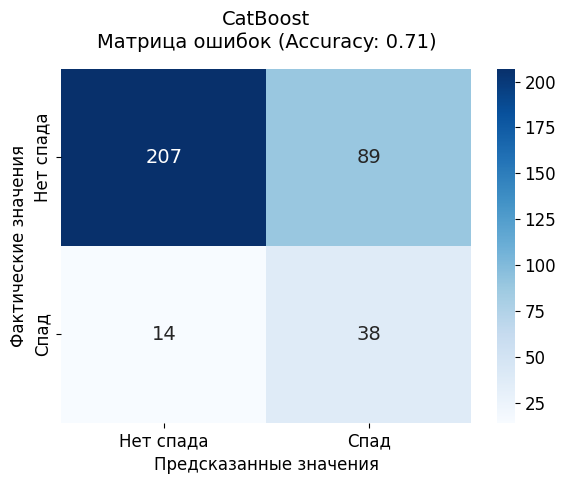

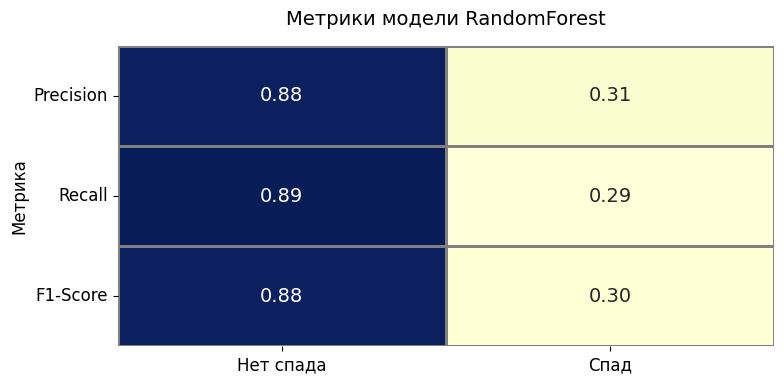

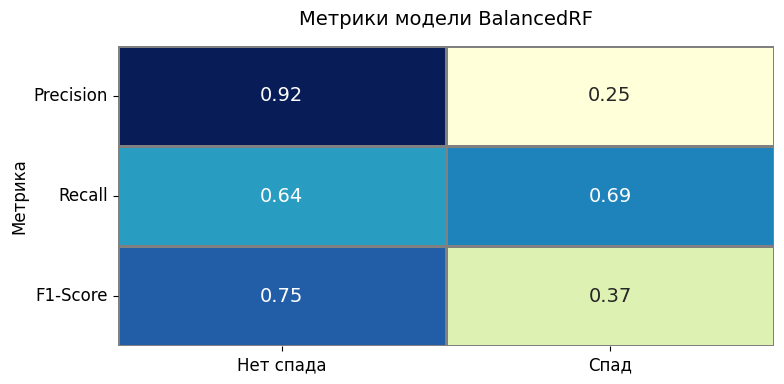

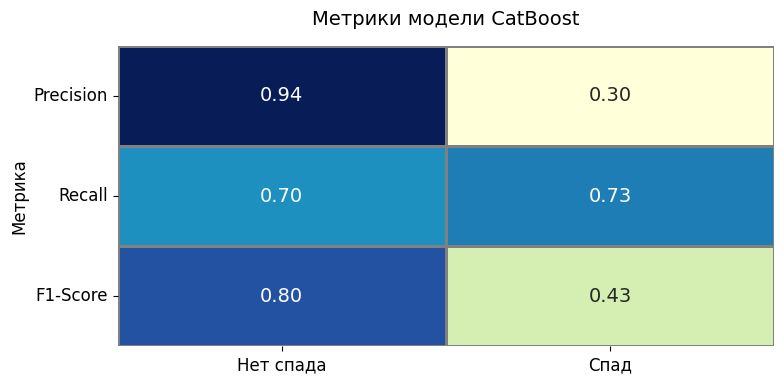

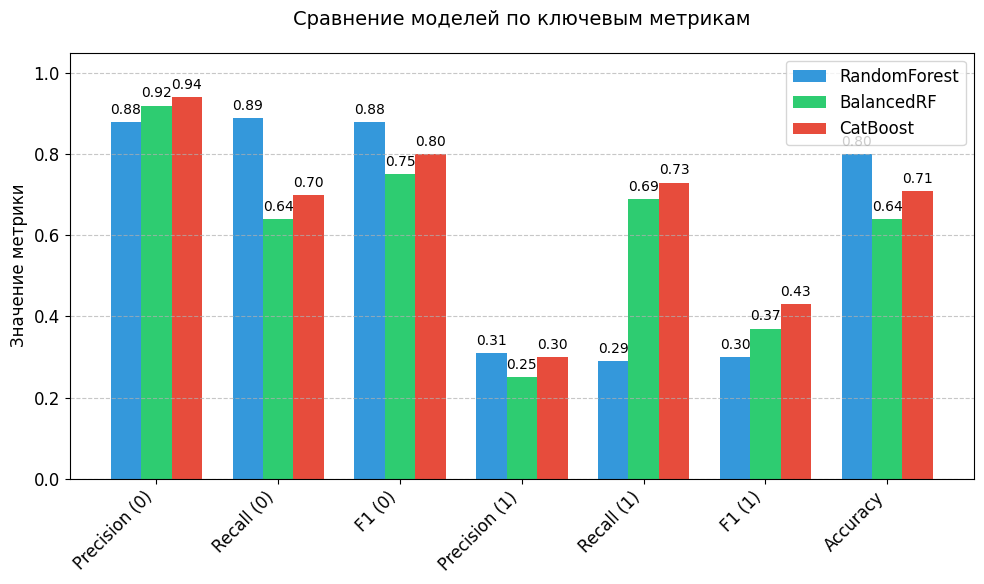

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Конфигурация стиля

sns.set_palette("pastel")
plt.rcParams['font.size'] = 12

# 1. Матрицы ошибок (отдельные графики)
def plot_confusion_matrix(cm, model_name, accuracy):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Нет спада', 'Спад'],
                yticklabels=['Нет спада', 'Спад'],
                annot_kws={"size": 14})
    plt.title(f'{model_name}\nМатрица ошибок (Accuracy: {accuracy:.2f})', pad=15, fontsize=14)
    plt.xlabel('Предсказанные значения', fontsize=12)
    plt.ylabel('Фактические значения', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{model_name}.png', dpi=120, bbox_inches='tight')
    plt.show()

# Данные для матриц ошибок
confusion_matrices = {
    'RandomForest': {
        'matrix': np.array([[263, 33], [37, 15]]),
        'accuracy': 0.80
    },
    'BalancedRF': {
        'matrix': np.array([[189, 107], [16, 36]]),
        'accuracy': 0.64
    },
    'CatBoost': {
        'matrix': np.array([[207, 89], [14, 38]]),
        'accuracy': 0.71
    }
}

# Генерация матриц ошибок
for model_name, data in confusion_matrices.items():
    plot_confusion_matrix(data['matrix'], model_name, data['accuracy'])

# 2. Тепловые карты метрик (отдельные графики)
def plot_metrics_heatmap(metrics, model_name):
    df = pd.DataFrame({
        'Метрика': ['Precision', 'Recall', 'F1-Score'],
        'Нет спада': metrics['Нет спада'],
        'Спад': metrics['Спад']
    }).set_index('Метрика')

    plt.figure(figsize=(8, 4))
    sns.heatmap(df, annot=True, fmt=".2f", cmap="YlGnBu",
                cbar=False, linewidths=1, linecolor='gray',
                annot_kws={"size": 14})
    plt.title(f'Метрики модели {model_name}', pad=15, fontsize=14)
    plt.xticks(rotation=0, fontsize=12)
    plt.yticks(rotation=0, fontsize=12)
    plt.tight_layout()
    plt.savefig(f'metrics_{model_name}.png', dpi=120, bbox_inches='tight')
    plt.show()

# Данные для тепловых карт
metrics_data = {
    'RandomForest': {
        'Нет спада': [0.88, 0.89, 0.88],
        'Спад': [0.31, 0.29, 0.30]
    },
    'BalancedRF': {
        'Нет спада': [0.92, 0.64, 0.75],
        'Спад': [0.25, 0.69, 0.37]
    },
    'CatBoost': {
        'Нет спада': [0.94, 0.70, 0.80],
        'Спад': [0.30, 0.73, 0.43]
    }
}

# Генерация тепловых карт
for model_name, metrics in metrics_data.items():
    plot_metrics_heatmap(metrics, model_name)

# 3. Сводный график сравнения моделей
plt.figure(figsize=(10, 6))
metrics = ['Precision (0)', 'Recall (0)', 'F1 (0)', 'Precision (1)', 'Recall (1)', 'F1 (1)', 'Accuracy']
x = np.arange(len(metrics))
width = 0.25

# Данные для графиков
rf_data = [0.88, 0.89, 0.88, 0.31, 0.29, 0.30, 0.80]
brf_data = [0.92, 0.64, 0.75, 0.25, 0.69, 0.37, 0.64]
cat_data = [0.94, 0.70, 0.80, 0.30, 0.73, 0.43, 0.71]

plt.bar(x - width, rf_data, width, label='RandomForest', color='#3498db')
plt.bar(x, brf_data, width, label='BalancedRF', color='#2ecc71')
plt.bar(x + width, cat_data, width, label='CatBoost', color='#e74c3c')

plt.xticks(x, metrics, rotation=45, ha='right')
plt.ylabel('Значение метрики')
plt.title('Сравнение моделей по ключевым метрикам', pad=20, fontsize=14)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, 1.05)

# Добавление значений на столбцы
for i, (rf_val, brf_val, cat_val) in enumerate(zip(rf_data, brf_data, cat_data)):
    plt.text(i - width, rf_val + 0.02, f'{rf_val:.2f}', ha='center', fontsize=10)
    plt.text(i, brf_val + 0.02, f'{brf_val:.2f}', ha='center', fontsize=10)
    plt.text(i + width, cat_val + 0.02, f'{cat_val:.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('models_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## (Соня) Подпроблема 3: Выявление ключевых факторов


Хотим понять: почему одни товары заказывают больше, чем другие?
Для этого мы используем дерево решений — оно показывает пошаговую логику: какие признаки влияют на спрос и в какой последовательности.

In [ ]:
# Удаляем лишние столбцы
df = df.drop(columns=['Order ID','EmailID','Geography', 'Country','Product Name','Ship Date'])

df1 = df.copy()

df1.head(3)

,Order Date,Category,Sales,Quantity,Profit,Manufacturer,City,State,StateCode,OrderMonth,OrderWeekday,ShippingDays,OrderYear,Price_per_Item
0,2013-06-13,Labels,14.62,2,6.8714,others,Los Angeles,California,CA,6,3,4,2013,7.31
1,2011-06-09,Furnishings,48.86,7,14.1694,eldon,Los Angeles,California,CA,6,3,5,2011,6.98
2,2011-06-09,Art,7.28,4,1.9656,newell,Los Angeles,California,CA,6,3,5,2011,1.82


In [ ]:
# Показываем структуру данных
df.info(), df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3203 entries, 0 to 3202
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order Date      3203 non-null   datetime64[ns]
 1   Category        3203 non-null   object        
 2   Sales           3203 non-null   float64       
 3   Quantity        3203 non-null   int64         
 4   Profit          3203 non-null   float64       
 5   Manufacturer    3203 non-null   object        
 6   City            3203 non-null   object        
 7   State           3203 non-null   object        
 8   StateCode       3203 non-null   object        
 9   OrderMonth      3203 non-null   int32         
 10  OrderWeekday    3203 non-null   int32         
 11  ShippingDays    3203 non-null   int64         
 12  OrderYear       3203 non-null   int32         
 13  Price_per_Item  3203 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int32(3), int64(2), ob

(None,
                            Order Date Category         Sales     Quantity  \
 count                            3203     3203   3203.000000  3203.000000   
 unique                            NaN       17           NaN          NaN   
 top                               NaN  Binders           NaN          NaN   
 freq                              NaN      471           NaN          NaN   
 mean    2013-05-10 03:06:07.530440192      NaN    226.493233     3.828910   
 min               2011-01-07 00:00:00      NaN      0.990000     1.000000   
 25%               2012-05-22 00:00:00      NaN     19.440000     2.000000   
 50%               2013-07-22 00:00:00      NaN     60.840000     3.000000   
 75%               2014-05-23 00:00:00      NaN    215.809000     5.000000   
 max               2014-12-31 00:00:00      NaN  13999.960000    14.000000   
 std                               NaN      NaN    524.876877     2.260947   
 
              Profit Manufacturer         City       St

На графиках видно:

**Quantity:** подавляющее большинство значений находится ниже 20. Всё, что выше, — это редкие экстремальные случаи - убираем как выбросы.

**Sales:** плотное распределение до ~1000. Значения выше — одиночные высокие транзакции, можно считать выбросами.

**Profit:** большинство значений — ниже 300. Выше - это редкие и влияют на масштаб графика.

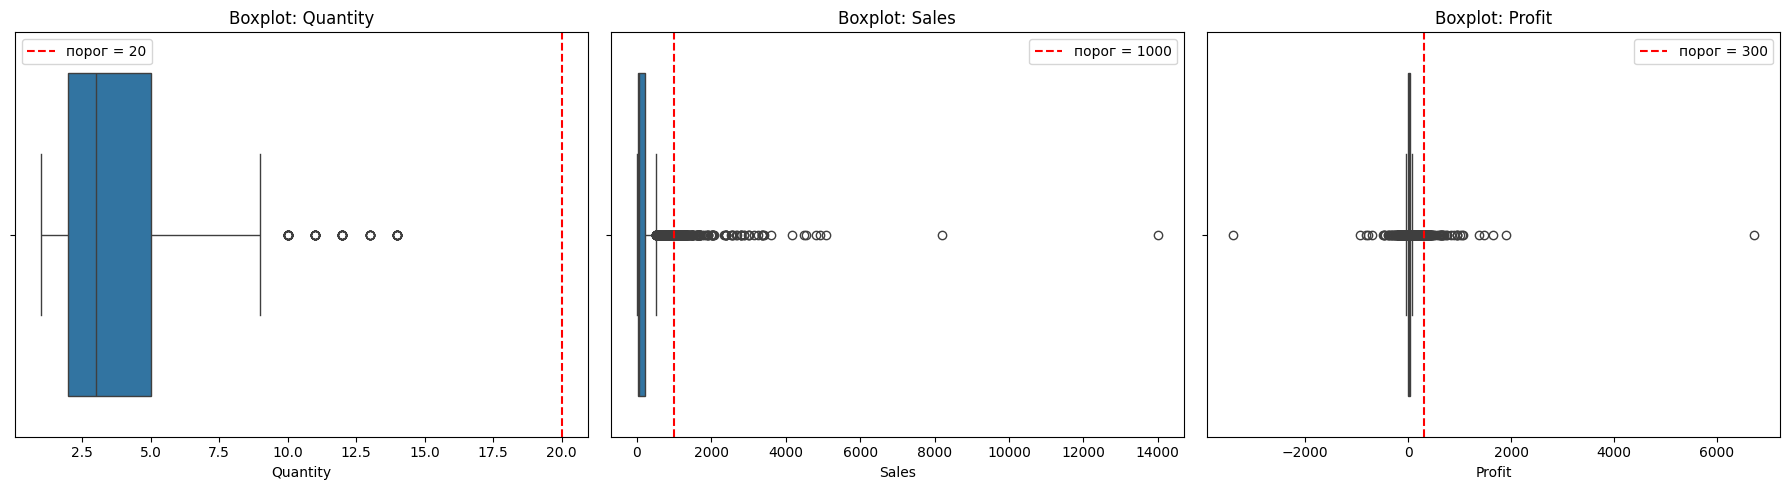

In [ ]:
# Построим графики распределения и выбросов до фильтрации
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Quantity
sns.boxplot(data=df1, x='Quantity', ax=axs[0])
axs[0].set_title("Boxplot: Quantity")
axs[0].axvline(20, color='red', linestyle='--', label='порог = 20')
axs[0].legend()

# Sales
sns.boxplot(data=df1, x='Sales', ax=axs[1])
axs[1].set_title("Boxplot: Sales")
axs[1].axvline(1000, color='red', linestyle='--', label='порог = 1000')
axs[1].legend()

# Profit
sns.boxplot(data=df1, x='Profit', ax=axs[2])
axs[2].set_title("Boxplot: Profit")
axs[2].axvline(300, color='red', linestyle='--', label='порог = 300')
axs[2].legend()

plt.tight_layout()
plt.show()

Около 21,3 % удалено как выбросы

In [ ]:
# Удаление утечек данных
if 'Profit' in df1.columns:
    df1.drop(columns=["Profit"], inplace=True)

# Обработка выбросов с помощью IQR
def iqr_filter(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]

# Применяем фильтрацию выбросов
for col in ['Sales', 'Quantity']:
    df1 = iqr_filter(df1, col)


## ШАГ 2: Создание признаков

In [ ]:
#  Создание новых признаков
df1["Price_per_Item"] = df1["Sales"] / df1["Quantity"]

# Обработка категориальных признаков
# Определяем колонки для обработки
one_hot_cols = [
    "Category", "OrderMonth", "OrderWeekday", "ShippingGapCategory",
    "IsWeekend", "IsFastShipping", "HighValueOrder"
]

high_cardinality = ["Manufacturer", "City", "State", "StateCode", "Order Date"]

In [ ]:
# One-Hot Encoding прямо
for col in one_hot_cols:
    if col in df1.columns:
        dummies = pd.get_dummies(df1[col], prefix=col, drop_first=True)
        df1 = pd.concat([df1.drop(columns=[col]), dummies], axis=1)

# Удаляем признаки
df1.drop(columns=high_cardinality, inplace=True, errors='ignore')

# Масштабирование числовых признаков
numerical_features = ["Sales", "DiscountRate", "Price_per_Item"]
scaler = StandardScaler()
df1[numerical_features] = scaler.fit_transform(df1[numerical_features])

In [ ]:
df1.head(5)

,Order Date,Category,Sales,Quantity,Profit,Manufacturer,City,State,StateCode,OrderMonth,OrderWeekday,ShippingDays,OrderYear,IsWeekend,IsFastShipping,DiscountRate,HighValueOrder,ShippingGapCategory
0,2013-06-13,Labels,14.620,2,6.8714,others,Los Angeles,California,CA,6,3,4,2013,0,0,0.4700,0,Medium
1,2011-06-09,Furnishings,48.860,7,14.1694,eldon,Los Angeles,California,CA,6,3,5,2011,0,0,0.2900,0,Slow
2,2011-06-09,Art,7.280,4,1.9656,newell,Los Angeles,California,CA,6,3,5,2011,0,0,0.2700,0,Slow
3,2011-06-09,Phones,907.152,4,90.7152,others,Los Angeles,California,CA,6,3,5,2011,0,0,0.1000,1,Slow
4,2011-06-09,Binders,18.504,3,5.7825,others,Los Angeles,California,CA,6,3,5,2011,0,0,0.3125,0,Slow


 ## ШАГ 3: Обучение базового Decision Tree

Ключевые моменты:

Высокая точность: Дерево Решений достигло  R^2 в 0.59, что указывает на его хорошую предсказательную способность.

Доминирующие факторы: Price_per_Item (цена за единицу) и Sales (сумма продаж) являются ключевыми драйверами спроса, объясняя большую часть вариативности в Quantity.

Многие признаки, включая год и некоторые категории, не играют роли в этой модели, что может указывать на их слабую связь с Quantity или на то, что их влияние уже учтено через цену и продажи.

Бизнес-инсайты:

1. Ценообразование: Цена за единицу — важнейший фактор.

2. Объем продаж: Общая сумма заказа сильно влияет на количество купленных единиц.

In [ ]:
# Целевая переменная и признаки
target = "Quantity"
y = df1[target]
X = df1.drop(columns=[target])

#  Обработка даты
if "Order Date" in X.columns:
    X["Order Date"] = pd.to_datetime(X["Order Date"], errors='coerce')
    X["Order Date"] = X["Order Date"].astype("int64") // 10**9

#  One-hot кодирование
features_encoded = pd.get_dummies(X, drop_first=True)

# Train/test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    features_encoded, y, test_size=0.2, random_state=42
)

# Обучение дерева решений
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

tree = DecisionTreeRegressor(random_state=42, max_depth=6)
tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)

#  Метрики
metrics = {
    "R2": r2_score(y_test, y_pred),
    "MAE": mean_absolute_error(y_test, y_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
}

# Важность признаков
importances = pd.Series(tree.feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False).head(10)

#  Вывод
print("Результаты модели Decision Tree ")
for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nТоп-10 важных признаков:")
print(top_features.to_string())



=== Результаты модели Decision Tree ===
R2: 0.6914
MAE: 0.8427
RMSE: 1.2359

Топ-10 важных признаков:
Price_per_Item         0.479972
Sales                  0.407590
Profit                 0.111603
Category_Binders       0.000450
Manufacturer_wilson    0.000211
ShippingDays           0.000124
OrderYear              0.000050
OrderWeekday           0.000000
Order Date             0.000000
OrderMonth             0.000000

Размер обучающей выборки: 2562
Размер тестовой выборки: 641
Среднее значение Quantity: 3.83


Модель в первую очередь делит по Sales и Profit_per_Item - это главные детерминанты спроса.

Затем уже идут уточняющие разветвления по Profit_per_Item, а не по категориям или логическим флагам (IsWeekend и т.п.).

Дерево имеет сложную структуру с множеством условий:

Основные разделения происходят по признакам Sales и Price per item
Условия используют пороговые значения в нормализованном виде (например, Sales <= -0.718)

Некоторые узлы имеют очень высокую квадратичную ошибку (до 25.98), что указывает на высокую дисперсию в этих узлах

Интерпретация некоторых узлов:

1. Корневой узел: Sales <= -0.718 с 3.232 samples, средним значением 3.552 и ошибкой 3.714

2. Узел с наибольшим количеством samples: 15.5 samples при Sales <= -0.658 со средним значением 5.133 и высокой ошибкой 25.98

3. Узел с наименьшей ошибкой: 0.725 при Sales <= -0.752 с 1.03 samples и средним значением 1.13



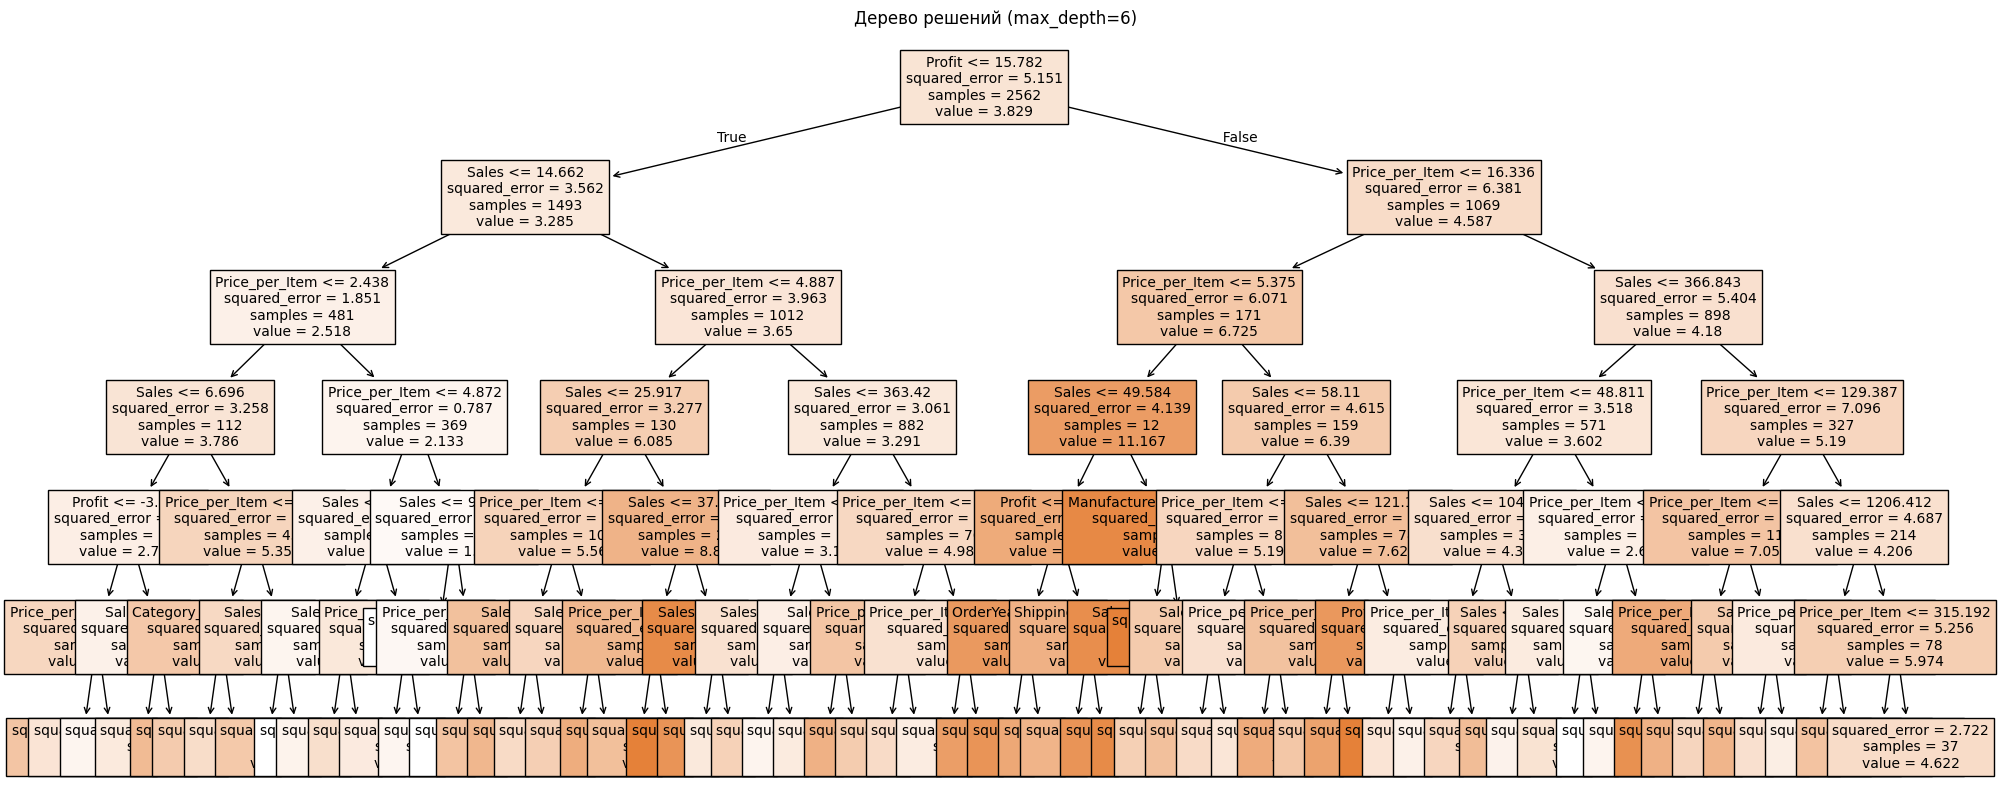

In [ ]:
# Визуализация дерева

plt.figure(figsize=(24, 10))
plot_tree(tree, feature_names=X_train.columns, filled=True, fontsize=10)
plt.title("Дерево решений (max_depth=6)")
plt.show()

## ШАГ 4: Random Forest

Используется RandomForestRegressor со 100 деревьями, максимальной глубиной 6 и фиксированным random_state=4.


Интерпретация результатов:

- MAE = 0.3669: В среднем предсказания модели отклоняются от реальных значений на ~0.37 единицы количества товара.

- RMSE = 0.5799: Показывает, что типичное отклонение предсказаний составляет ~0.58 единиц.

- R² = 0.72: Очень высокий показатель, означающий, что модель объясняет ~72% дисперсии целевой переменной.

In [ ]:
# Подготовка данных
X = df1.drop(columns=["Quantity"])
y = df1["Quantity"]

# Преобразуем Order Date
if "Order Date" in X.columns:
    X["Order Date"] = pd.to_datetime(X["Order Date"], errors='coerce')
    X["Order Date"] = X["Order Date"].astype("int64") // 10**9

# Train/Test split ДО кодирования (чтобы избежать утечек)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2024
)

# One-hot кодирование (отдельно для train и test)
# Синхронизируем колонки после кодирования
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# Добавляем отсутствующие колонки в тест (чтобы структура совпадала)
missing_cols = set(X_train_encoded.columns) - set(X_test_encoded.columns)
for col in missing_cols:
    X_test_encoded[col] = 0

# Упорядочим колонки
X_test_encoded = X_test_encoded[X_train_encoded.columns]

# Обучение модели
model = RandomForestRegressor(n_estimators=100, max_depth=6, random_state=4)
model.fit(X_train_encoded, y_train)

# Оценка
y_pred = model.predict(X_test_encoded)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(" MAE:", round(mae, 3))
print(" RMSE:", round(rmse, 3))
print(" R^2:", round(r2, 3))

 MAE: 0.737
 RMSE: 1.181
 R^2: 0.721


## Проверка предсказаний


1. Модель хорошо предсказывает Quantity для большинства значений от 2 до 8.

2. При значениях Quantity > 8: видно небольшое систематическое занижение, модель боится предсказывать высокие значения.

3. Область предсказаний не шумная, что указывает на хорошую устойчивость

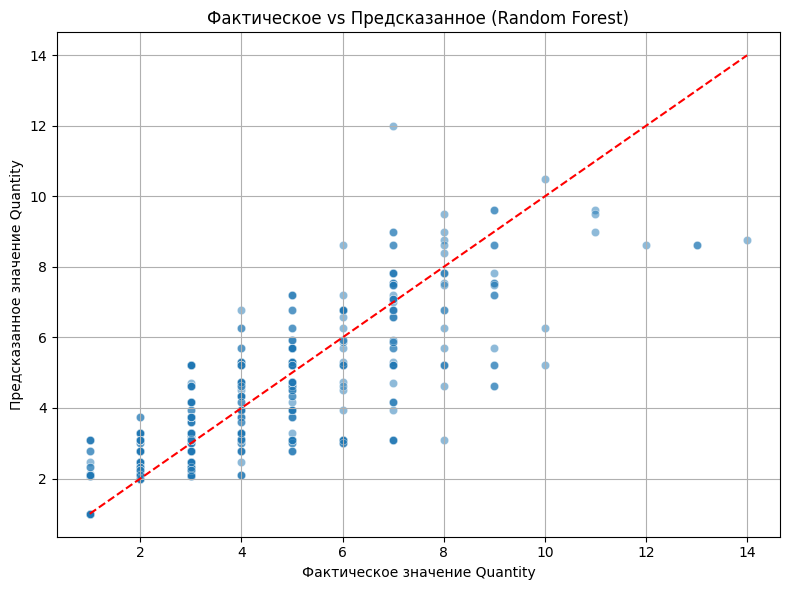

In [ ]:
# график фактических vs предсказанных значений
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Фактическое значение Quantity")
plt.ylabel("Предсказанное значение Quantity")
plt.title("Фактическое vs Предсказанное (Random Forest)")
plt.grid(True)
plt.tight_layout()
plt.show()

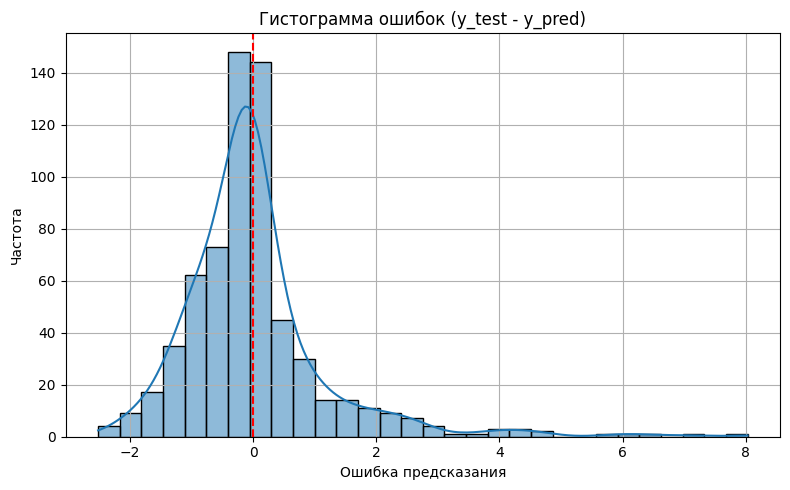

In [ ]:
# Расчёт ошибок
errors = y_test - y_pred

# гистограмма ошибок
plt.figure(figsize=(8, 5))
sns.histplot(errors, bins=30, kde=True)
plt.axvline(0, color='red', linestyle='--')
plt.title("Гистограмма ошибок (y_test - y_pred)")
plt.xlabel("Ошибка предсказания")
plt.ylabel("Частота")
plt.grid(True)
plt.tight_layout()
plt.show()

# Дальнейший тюнинг Random Forest


По сравнению с предыдущим результатом Случайного Леса (R^2: 0.18), эти метрики представляют собой огромный шаг вперед. Понизили объясняемую дисперсию с 72% до почти 63%.

In [ ]:
import time
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import randint

In [ ]:
# подготовка данных
y = df1['Quantity']
X = df1.drop(columns=['Quantity'])

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2029
)

# сетка параметров
param_dist = {
    'n_estimators': randint(100, 300),
    'max_depth': randint(5, 20),
    'min_samples_split': randint(2, 10),
    'max_features': ['sqrt', 'log2']
}

# модель + RandomizedSearchCV
rf = RandomForestRegressor(random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=30,
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=1,
    verbose=1
)

# обучение
start = time.time()
random_search.fit(X_train, y_train)
end = time.time()

# оценка
best_rf = random_search.best_estimator_
y_pred = best_rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Время обучения:", round(end - start, 1), "секунд")
print(" Лучшие параметры:", random_search.best_params_)
print("MAE:", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R^2:", round(r2, 3))


Fitting 3 folds for each of 30 candidates, totalling 90 fits
Время обучения: 81.0 секунд
 Лучшие параметры: {'max_depth': 18, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 289}
MAE: 0.925
RMSE: 1.186
R^2: 0.635


## Анализ важности признаков (feature_importances_)

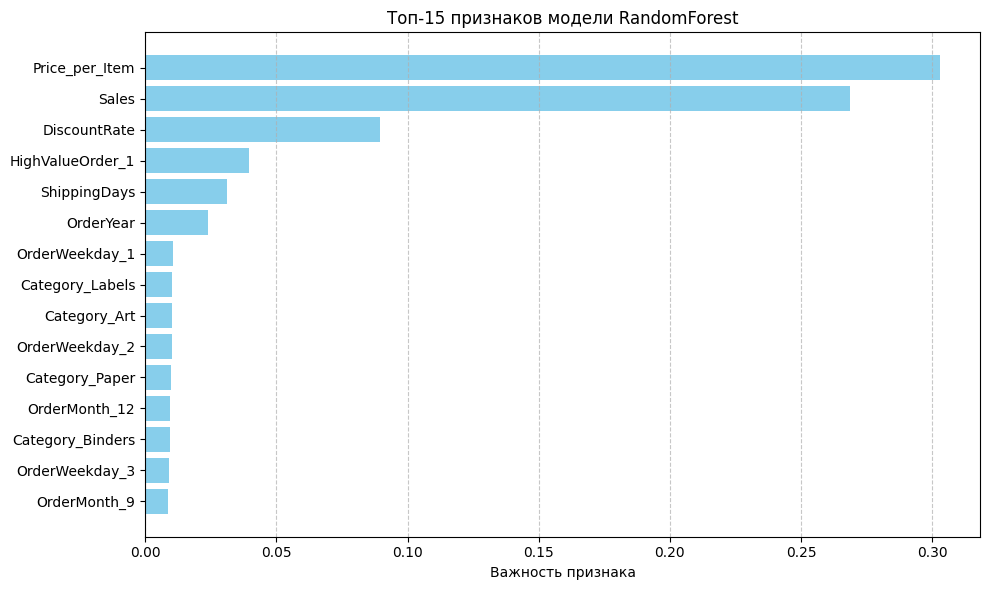

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Получаем важность признаков
feature_importances = best_rf.feature_importances_
features_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)

# Выберем топ-15 признаков
top_features = features_df.head(15)

# Построим горизонтальный график
plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Importance'], color='skyblue')
plt.xlabel('Важность признака')
plt.title('Топ-15 признаков модели RandomForest')
plt.gca().invert_yaxis()  # чтобы важные признаки были сверху
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# График зависимостей

# Зависимости переменной `Quantity` от топ-5 признаков

### 1. **Sales (Объём продаж)**
- *Наблюдение:* присутствует слабая положительная связь между `Sales` и `Quantity`.
- *Интерпретация:* большинство заказов с низкой суммой включает малое количество товаров; более дорогие заказы могут содержать как малое, так и большое количество позиций.


### 2. **ProfitPerItem (Прибыль с единицы товара)**
- *Наблюдение:* большинство значений сосредоточено около нуля, но при умеренной прибыли `Quantity` может быть выше.
- *Интерпретация:* высокая прибыль за штуку часто соответствует низкому количеству (например, дорогая техника), а массовые покупки — с меньшей маржой.


### 3. **DiscountRate (Скидка)**
- *Наблюдение:* на скидках 40–50% иногда фиксируются высокие значения `Quantity`, но разброс остаётся значительным.
-  *Интерпретация:* акции стимулируют рост объёма заказа, но это не универсальное правило, также зависит от типа продукта.

### 4. **ShippingDays (Срок доставки)**
-  *Наблюдение:* медиана `Quantity` остаётся стабильной для всех значений срока доставки.
- *Интерпретация:* срок доставки почти не влияет на количество покупаемых товаров — вероятно, этот фактор менее значим при принятии решения.

### 5. **ProductGroup_Office (Офисные товары)**

- *Наблюдение:* офисные товары имеют чуть более высокую медиану `Quantity`.
- *Интерпретация:* офисные заказы (канцелярия, бумага) совершаются в больших объёмах, особенно в B2B-сегменте.


### Выводы:
- На `Quantity` влияют как числовые признаки (цена, скидка, прибыль), так и бинарные характеристики (категория товара).
- Данные демонстрируют *нелинейные и шумные зависимости*, что обосновывает использование ансамблевых моделей.
- Некоторые признаки (как `ShippingDays`) оказывают слабое влияние и могут быть рассмотрены к исключению или снижению веса.



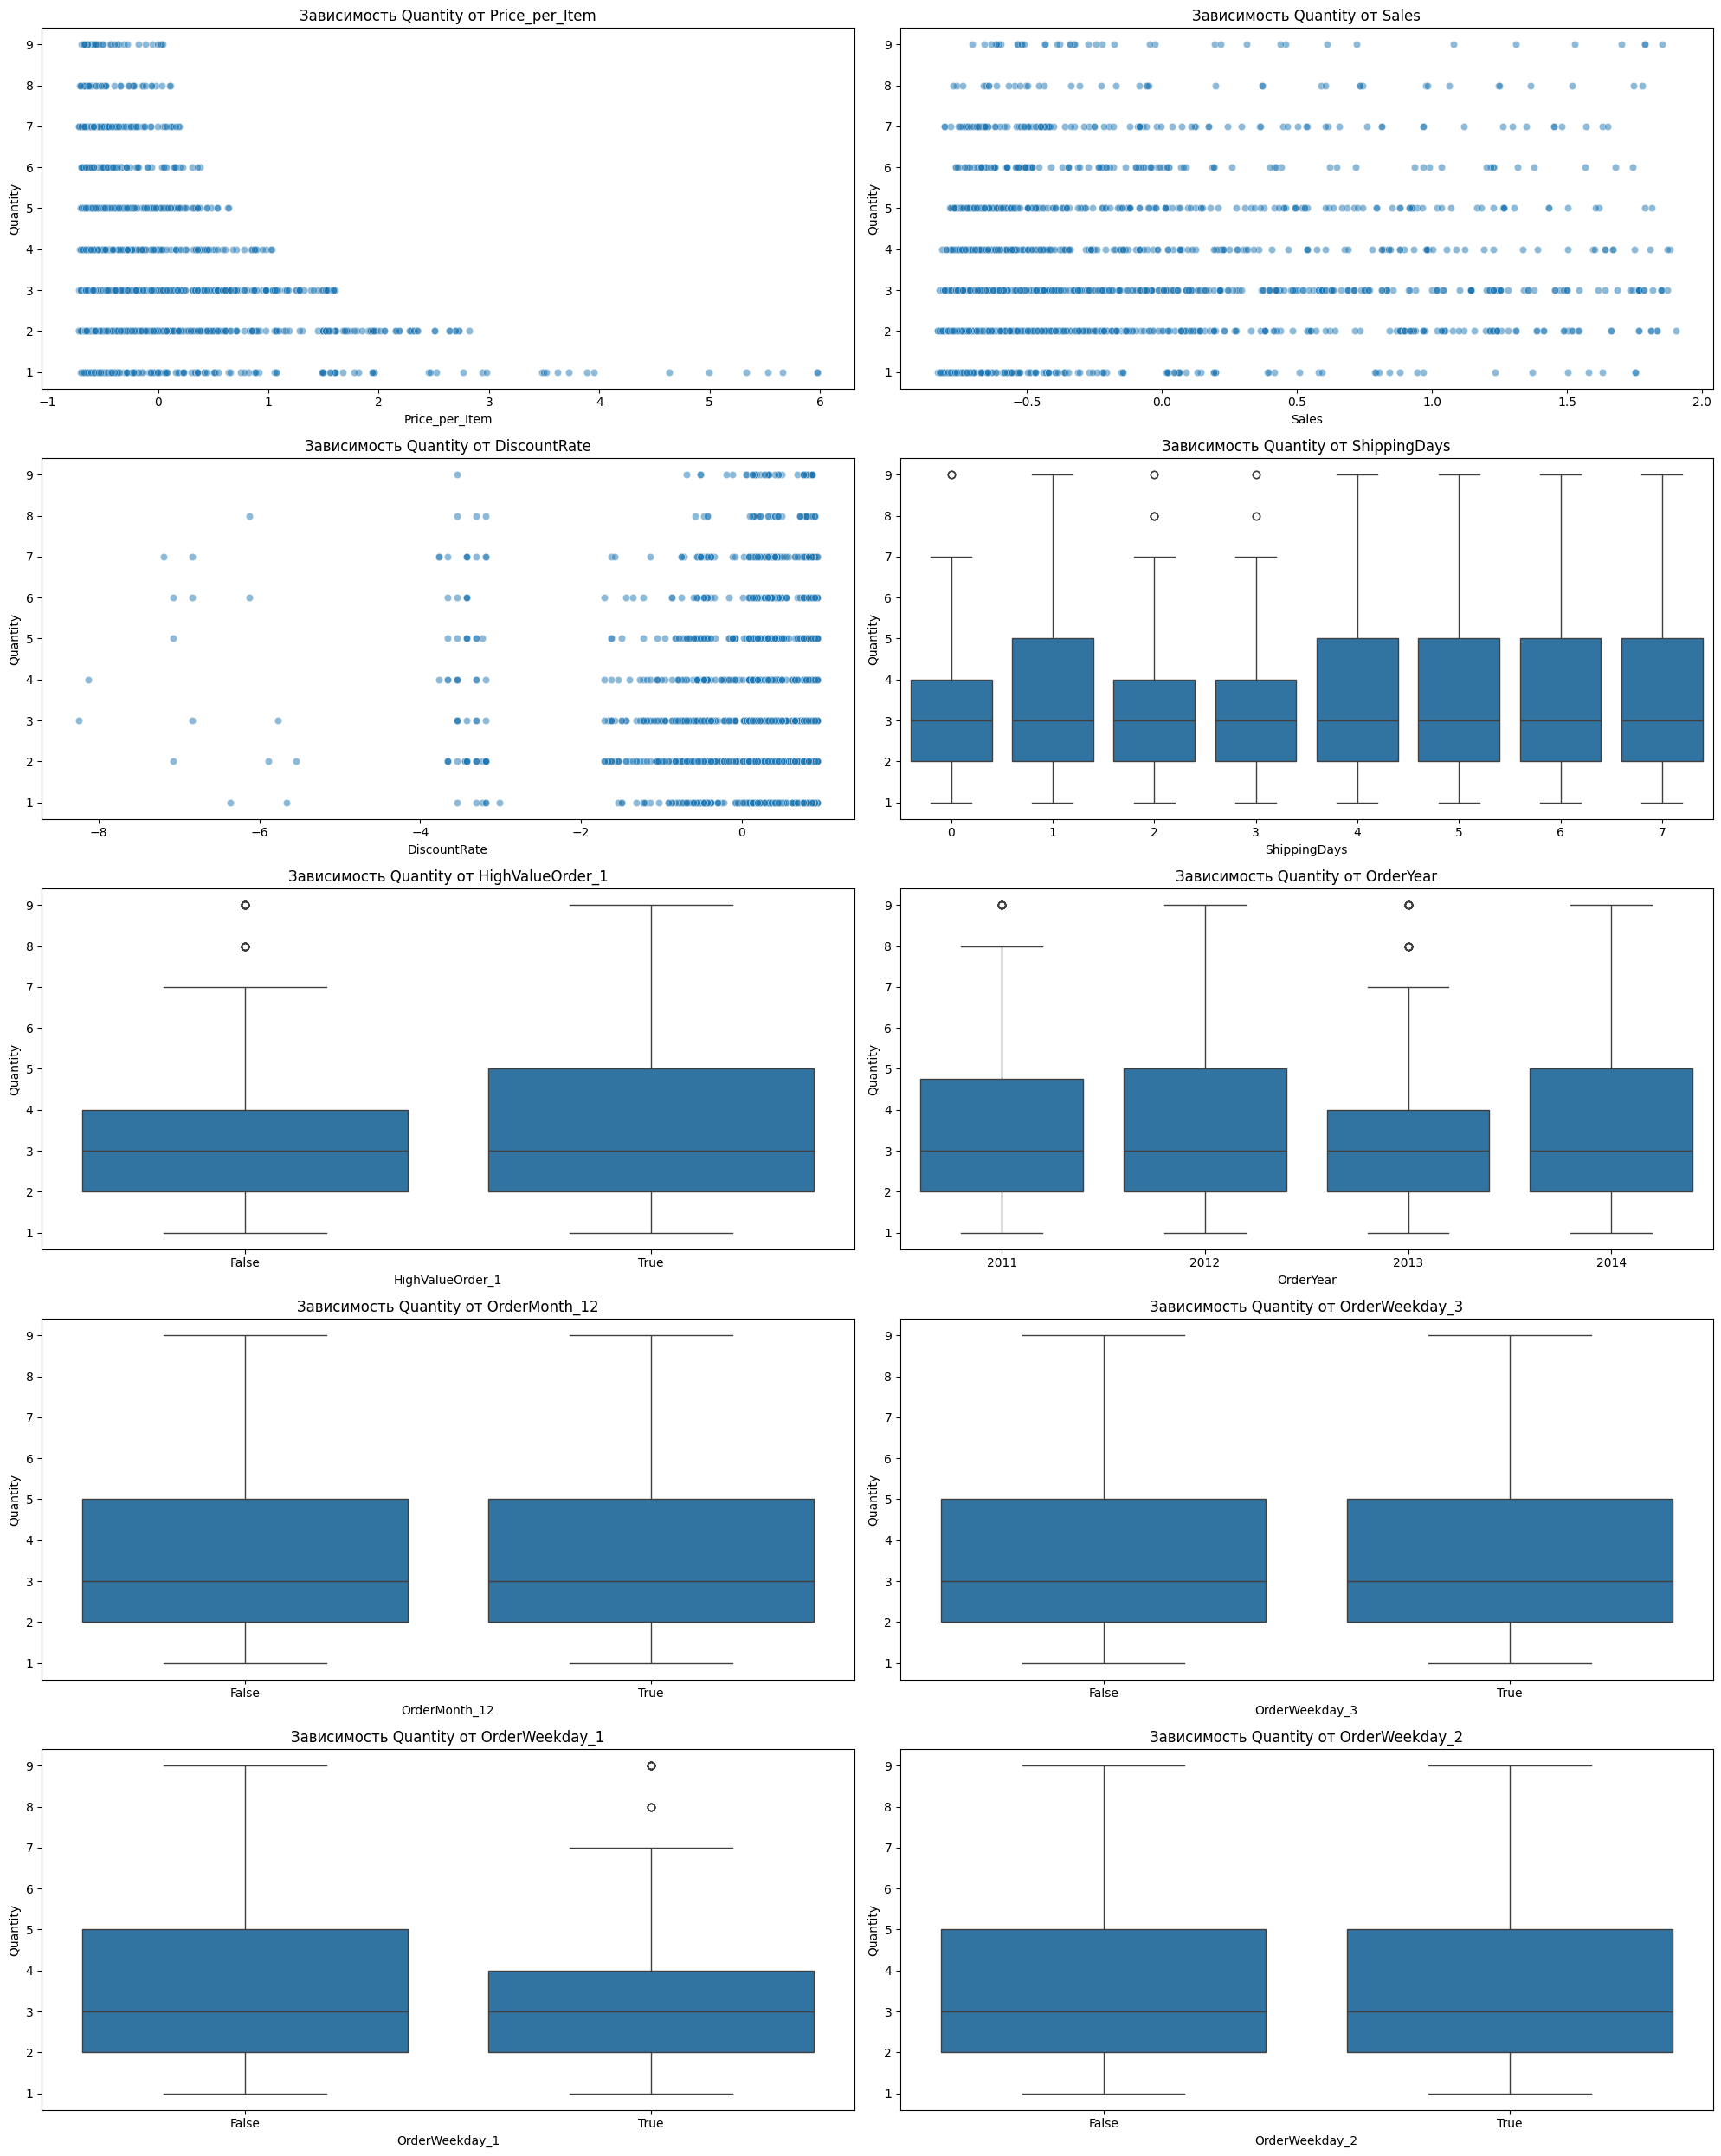

In [ ]:
# Обучение модели
model = RandomForestRegressor(n_estimators=289, max_depth=18, random_state=42)
model.fit(X_train, y_train)

# Получение топ-10 признаков
importances = pd.Series(model.feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False).head(10).index

# Построение графиков
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(20, 25))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    if X_train[feature].nunique() <= 10:
        sns.boxplot(x=X_train[feature], y=y_train, ax=axes[i])
    else:
        sns.scatterplot(x=X_train[feature], y=y_train, alpha=0.5, ax=axes[i])
    axes[i].set_title(f"Зависимость Quantity от {feature}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Quantity")

plt.tight_layout()
plt.show()

### Cравнения метрик двух моделей Random Forest


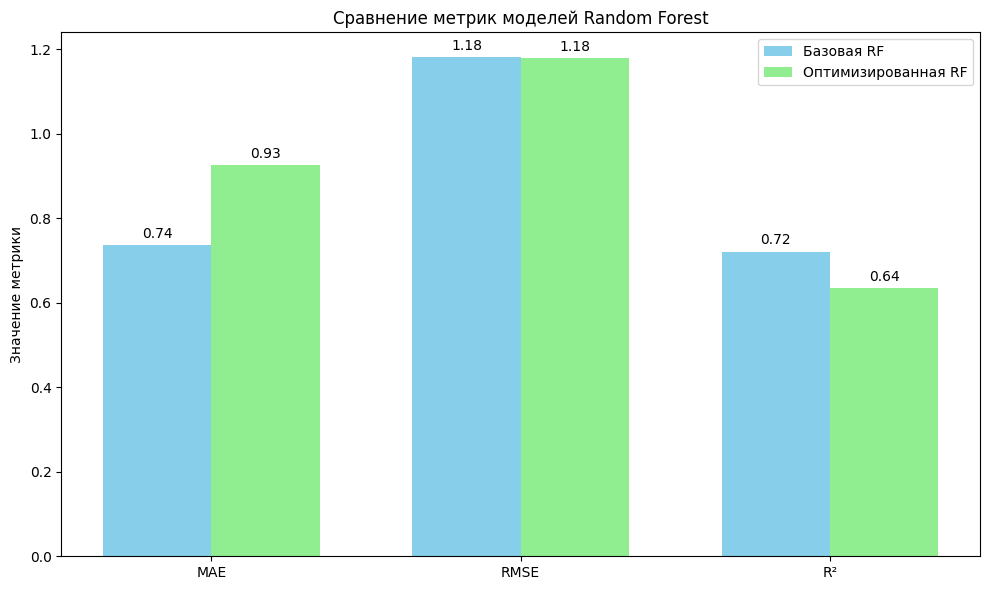

In [ ]:
# Метрики базовой модели RF
base_metrics = {
    'MAE': 0.737,
    'RMSE': 1.181,
    'R2': 0.721
}

# Метрики оптимизированной модели RF
optimized_metrics = {
    'MAE': 0.925,
    'RMSE': 1.18,
    'R2': 0.635
}

# Создаем данные для графиков
metrics_names = ['MAE', 'RMSE', 'R²']
base_values = [base_metrics['MAE'], base_metrics['RMSE'], base_metrics['R2']]
optimized_values = [optimized_metrics['MAE'], optimized_metrics['RMSE'], optimized_metrics['R2']]

x = np.arange(len(metrics_names))  # позиции метрик
width = 0.35

# Создаем график
fig, ax = plt.subplots(figsize=(10, 6))

# Столбцы для базовой модели
rects1 = ax.bar(x - width/2, base_values, width, label='Базовая RF', color='skyblue')

# Столбцы для оптимизированной модели
rects2 = ax.bar(x + width/2, optimized_values, width, label='Оптимизированная RF', color='lightgreen')

# Добавляем подписи
ax.set_ylabel('Значение метрики')
ax.set_title('Сравнение метрик моделей Random Forest')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend()

# Добавляем значения на столбцы
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

## Сегментация по поведению

### Сегмент: Office

1. Заказы в этом сегменте в среднем содержат почти 4 товара — выше общего среднего.

2. При высокой скидке (≈47%) сохраняется достаточный уровень прибыли.

3. Категория Office реагирует положительно на скидки. Возможен потенциал для акций и промо-кампаний.

In [ ]:
# фильтрация сегмента
segment_df = df1[(df1['ProductGroup'] == 'Office') & (df1['DiscountRate'] > 0.4)]

# краткая сводка по сегменту
summary = {
    "Количество заказов в сегменте": len(segment_df),
    "Среднее количество товаров (Quantity)": segment_df["Quantity"].mean(),
    "Средний объём продаж (Sales)": segment_df["Sales"].mean(),
    "Средняя прибыль (Profit)": segment_df["Profit"].mean(),
    "Средняя скидка (DiscountRate)": segment_df["DiscountRate"].mean(),
}

summary

{'Количество заказов в сегменте': 564,
 'Среднее количество товаров (Quantity)': np.float64(3.6684397163120566),
 'Средний объём продаж (Sales)': np.float64(52.6315780141844),
 'Средняя прибыль (Profit)': np.float64(25.047918262411347),
 'Средняя скидка (DiscountRate)': np.float64(0.4751772778232575)}

### Сегмент: Leisure

In [ ]:
# фильтрация сегмента
segment_df = df1[(df1['ProductGroup'] == 'Leisure') & (df1['DiscountRate'] > 0.4)]

# краткая сводка по сегменту
summary = {
    "Количество заказов в сегменте": len(segment_df),
    "Среднее количество товаров (Quantity)": segment_df["Quantity"].mean(),
    "Средний объём продаж (Sales)": segment_df["Sales"].mean(),
    "Средняя прибыль (Profit)": segment_df["Profit"].mean(),
    "Средняя скидка (DiscountRate)": segment_df["DiscountRate"].mean(),
}

summary

{'Количество заказов в сегменте': 70,
 'Среднее количество товаров (Quantity)': np.float64(3.7142857142857144),
 'Средний объём продаж (Sales)': np.float64(188.5902857142857),
 'Средняя прибыль (Profit)': np.float64(82.01706142857142),
 'Средняя скидка (DiscountRate)': np.float64(0.4409999724334788)}

### Сегмент: Technology  

In [ ]:
# фильтрация сегмента
segment_df = df1[(df1['ProductGroup'] == 'Technology') & (df1['DiscountRate'] > 0.4)]

# краткая сводка по сегменту
summary = {
    "Количество заказов в сегменте": len(segment_df),
    "Среднее количество товаров (Quantity)": segment_df["Quantity"].mean(),
    "Средний объём продаж (Sales)": segment_df["Sales"].mean(),
    "Средняя прибыль (Profit)": segment_df["Profit"].mean(),
    "Средняя скидка (DiscountRate)": segment_df["DiscountRate"].mean(),
}

summary

{'Количество заказов в сегменте': 7,
 'Среднее количество товаров (Quantity)': np.float64(4.0),
 'Средний объём продаж (Sales)': np.float64(3041.2614285714285),
 'Средняя прибыль (Profit)': np.float64(1441.6263142857144),
 'Средняя скидка (DiscountRate)': np.float64(0.4528571378726908)}

### Сегмент: Furniture

In [ ]:
# фильтрация сегмента
segment_df = df1[(df1['ProductGroup'] == 'Furniture') & (df1['DiscountRate'] > 0.4)]

# краткая сводка по сегменту
summary = {
    "Количество заказов в сегменте": len(segment_df),
    "Среднее количество товаров (Quantity)": segment_df["Quantity"].mean(),
    "Средний объём продаж (Sales)": segment_df["Sales"].mean(),
    "Средняя прибыль (Profit)": segment_df["Profit"].mean(),
    "Средняя скидка (DiscountRate)": segment_df["DiscountRate"].mean(),
}

summary

{'Количество заказов в сегменте': 62,
 'Среднее количество товаров (Quantity)': np.float64(3.9838709677419355),
 'Средний объём продаж (Sales)': np.float64(71.9524193548387),
 'Средняя прибыль (Profit)': np.float64(31.943),
 'Средняя скидка (DiscountRate)': np.float64(0.43790320387957127)}

## (Диана) Учет сезонности и временной динамики


Цель: использовать time series-подход для более точного прогноза


In [ ]:
data = df.copy()

In [ ]:
data.head()

,Order Date,Category,Sales,Quantity,Profit,Manufacturer,City,State,StateCode,ProductGroup,OrderMonth,OrderWeekday,ShippingDays,OrderYear
0,2013-06-13,Labels,14.620,2,6.8714,others,Los Angeles,California,CA,Office,6,3,4,2013
1,2011-06-09,Furnishings,48.860,7,14.1694,eldon,Los Angeles,California,CA,Furniture,6,3,5,2011
2,2011-06-09,Art,7.280,4,1.9656,newell,Los Angeles,California,CA,Leisure,6,3,5,2011
3,2011-06-09,Phones,907.152,4,90.7152,others,Los Angeles,California,CA,Technology,6,3,5,2011
4,2011-06-09,Binders,18.504,3,5.7825,others,Los Angeles,California,CA,Office,6,3,5,2011


Начало работы с временными рядами

Спрос

In [ ]:
# Создаем колонку с месяцем 'ГГГГ-ММ' для группировки
data['YearMonth'] = data['Order Date'].dt.to_period('M')

# Группируем по ProductGroup и месяцу, считаем сумму Quantity
monthly_quantity = data.groupby(['ProductGroup', 'YearMonth'])['Quantity'].sum().reset_index()

# Преобразуем YearMonth обратно в datetime
monthly_quantity['YearMonth'] = monthly_quantity['YearMonth'].dt.to_timestamp()

# Строим интерактивный график
fig = px.line(
    monthly_quantity,
    x='YearMonth',
    y='Quantity',
    color='ProductGroup',
    title='Сезонность продаж по группам продуктов (Quantity)',
    labels={'YearMonth': 'Месяц', 'Quantity': 'Количество продаж (Quantity)'}
)

fig.update_layout(
    xaxis=dict(tickangle=45),
    template='plotly_white',
    legend_title_text='ProductGroup'
)

fig.show()


Визуальный анализ временных рядов показал наличие сезонности в  товарных категориях:




*   Во всех группах есть пики в ноябре-декабре - перед праздниками
*   Почти во всех, кроме технологий, еще один пик в сентябре, а в технологиях в августе



In [ ]:
monthly_quantity = data.groupby(['YearMonth'])['Quantity'].sum().reset_index()

# Преобразуем YearMonth обратно в datetime
monthly_quantity['YearMonth'] = monthly_quantity['YearMonth'].dt.to_timestamp()

In [ ]:
#monthly_quantity.set_index('YearMonth', inplace=True)

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly_quantity['Quantity'])

print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -3.392775
p-value: 0.011208
Critical Values:
	1%: -3.578
	5%: -2.925
	10%: -2.601


Мы получили статистику теста Дики-Фуллера и p-value, который говорит, что нулевая гипотеза отвергается и ряд стационарный

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Обучение модели ARIMA
model = ARIMA(monthly_quantity['Quantity'], order=(1, 1, 1))
model_fit = model.fit()

# Вывод статистики модели
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:               Quantity   No. Observations:                   48
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -290.225
Date:                Sun, 29 Jun 2025   AIC                            586.451
Time:                        20:48:35   BIC                            592.001
Sample:                             0   HQIC                           588.540
                                 - 48                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3489      0.286      1.220      0.222      -0.212       0.910
ma.L1         -0.8349      0.174     -4.788      0.000      -1.177      -0.493
sigma2      1.334e+04   3116.081      4.281      0.0

Остатки случайны и нормально распределены - это хорошо

Возможна гетероскедастичность (неоднородность дисперии, но не подтверждается)

Большой вклад вносит MA-часть (скользящее среднее), AR-часть - нет (авторегрессии)

In [ ]:
from sklearn.metrics import r2_score

# Прогноз на 12 месяцев вперёд
forecast = model_fit.forecast(steps=12)

# Истинные значения для сравнения – последние 12 месяцев
true_values = monthly_quantity['Quantity'][-12:]

# Метрики
mse = mean_squared_error(true_values, forecast)
mae = mean_absolute_error(true_values, forecast)
r2 = r2_score(true_values, forecast)

print(f'MSE: {mse:.2f}')
print(f'MAE: {mae:.2f}')
print(f'R²: {r2:.3f}')


MSE: 28163.04
MAE: 153.38
R²: -0.550


Модель ARIMA не справляется с задачей

SARIMA — расширение модели ARIMA, которая учитывает сезонность. Она подходит, если в данных есть сезонные паттерны (например, декабрьские пики в нашем случае).

Основные параметры:

p, d, q — параметры ARIMA: авторегрессия, порядок дифференцирования, скользящее среднее.
P, D, Q, m — сезонные компоненты (аналогично), где m — длина сезона (например, 12 месяцев).

Применяем, когда есть явная сезонность и тренды

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Построение модели SARIMA
model = SARIMAX(monthly_quantity['Quantity'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
model_fit = model.fit()

# Прогноз на 12 месяцев
forecast = model_fit.forecast(steps=12)

# Оценка
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

true_values = monthly_quantity['Quantity'][-12:]  # последние 12 наблюдений
mse = mean_squared_error(true_values, forecast)
mae = mean_absolute_error(true_values, forecast)
r2 = r2_score(true_values, forecast)

print(f'MSE: {mse:.2f}')
print(f'MAE: {mae:.2f}')
print(f'R²: {r2:.3f}')


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning:

Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.



MSE: 8804.14
MAE: 89.61
R²: 0.515


- MSE лучше - ошибка в 3 раза меньше, чем у ARIMA.
- MAE лучше - средняя ошибка прогноза снизилась на 40%.
- R² - модель объясняет более 50% дисперсии, то есть она уже имеет смысл как предсказательная

Подберем параметры для SARIMA

In [ ]:
# Построение модели SARIMA
model = SARIMAX(monthly_quantity['Quantity'], order=(0, 2, 1), seasonal_order=(0, 2, 1, 12))
model_fit = model.fit()

# Прогноз на 12 месяцев
forecast = model_fit.forecast(steps=12)

# Оценка
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

true_values = monthly_quantity['Quantity'][-12:]  # последние 12 наблюдений
mse = mean_squared_error(true_values, forecast)
mae = mean_absolute_error(true_values, forecast)
r2 = r2_score(true_values, forecast)

print(f'MSE: {mse:.2f}')
print(f'MAE: {mae:.2f}')
print(f'R²: {r2:.3f}')

MSE: 2724.65
MAE: 45.68
R²: 0.850


Лучшие параметры: order=(0, 2, 1), seasonal_order=(0, 1, 2, 12)
MSE: 2172.07
MAE: 33.62
R²: 0.880


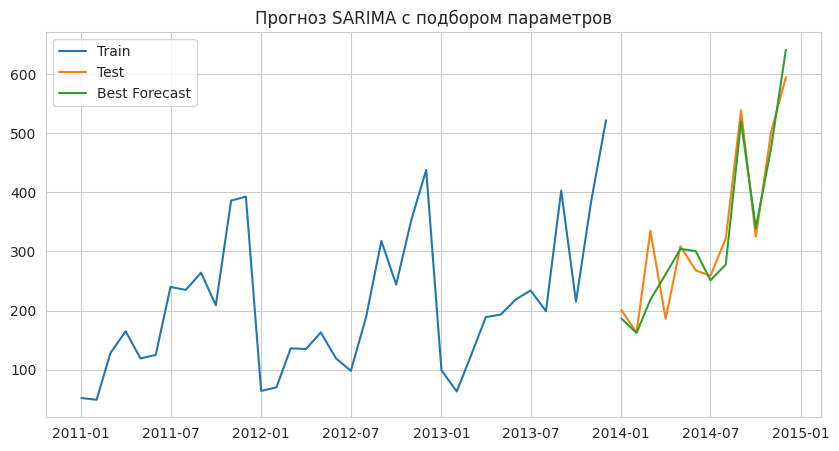

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

orders = [
    (0, 1, 1), (1, 1, 1), (0, 2, 1), (1, 0, 1),
    (1, 1, 0), (2, 1, 2), (2, 0, 1), (0, 1, 2)
]

seasonal_orders = [
    (0, 1, 1, 12), (1, 1, 1, 12), (0, 2, 1, 12),
    (1, 0, 1, 12), (1, 1, 0, 12), (2, 1, 2, 12),
    (0, 1, 2, 12), (2, 0, 1, 12)
]
y = monthly_quantity['Quantity']
if len(y) < 36:
    print("Недостаточно данных для адекватного обучения")
else:
    y_train, y_test = y[:-12], y[-12:]

    best_r2 = float('-inf')
    best_mae = float('inf')
    best_order = None
    best_seasonal_order = None
    best_forecast = None

    for order in orders:
        for seasonal_order in seasonal_orders:
            try:
                model = SARIMAX(y_train, order=order, seasonal_order=seasonal_order)
                model_fit = model.fit(disp=False)
                forecast = model_fit.forecast(steps=12)

                r2 = r2_score(y_test, forecast)
                mae = mean_absolute_error(y_test, forecast)

                if r2 > best_r2 or (r2 == best_r2 and mae < best_mae):
                    best_r2 = r2
                    best_mae = mae
                    best_order = order
                    best_seasonal_order = seasonal_order
                    best_forecast = forecast
            except Exception as e:
                continue

    print(f"Лучшие параметры: order={best_order}, seasonal_order={best_seasonal_order}")
    print(f"MSE: {mean_squared_error(y_test, best_forecast):.2f}")
    print(f"MAE: {best_mae:.2f}")
    print(f"R²: {best_r2:.3f}")

    # Визуализация
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10, 5))
    plt.plot(y_train.index, y_train, label='Train')
    plt.plot(y_test.index, y_test, label='Test')
    plt.plot(y_test.index, best_forecast, label='Best Forecast')
    plt.title('Прогноз SARIMA с подбором параметров')
    plt.legend()
    plt.show()


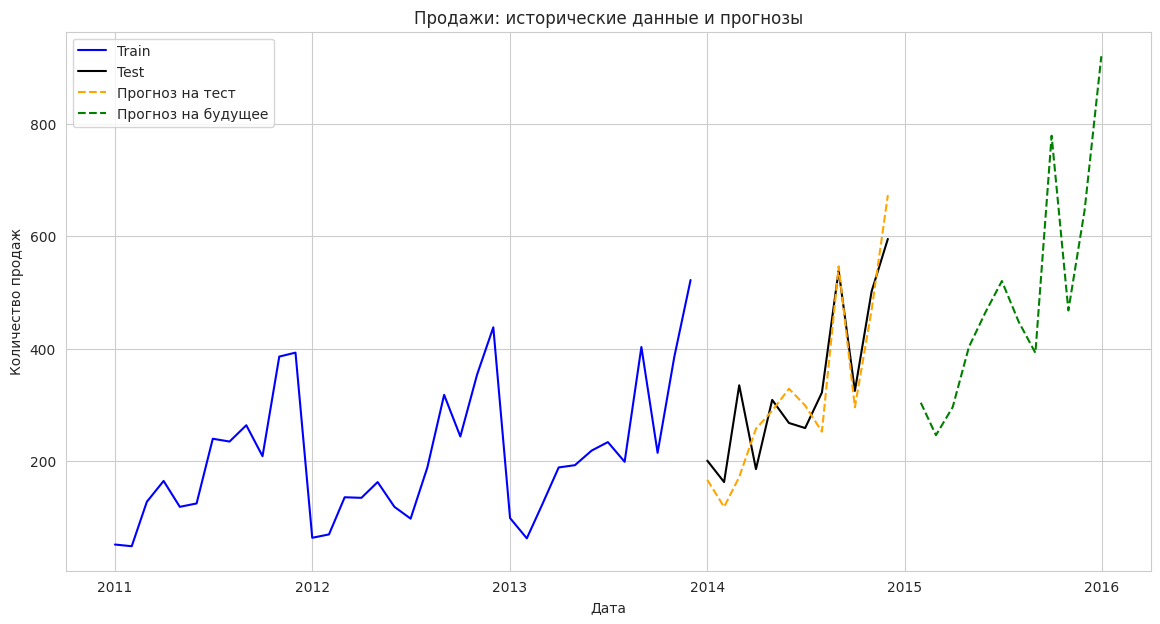

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Делим данные на train и test
train = monthly_quantity.iloc[:-12]
test = monthly_quantity.iloc[-12:]

# Строим модель на train
model = SARIMAX(train['Quantity'], order=(0, 2, 1), seasonal_order=(0, 2, 1, 12))
model_fit = model.fit()

# Прогноз на test (12 месяцев)
forecast_test = model_fit.forecast(steps=12)

# Прогноз на будущее (следующие 12 месяцев после test)
forecast_future = model_fit.forecast(steps=24)[12:]  # после теста идут следующие 12 месяцев

# Индексы для прогнозов
forecast_test_index = test.index
forecast_future_index = pd.date_range(start=test.index[-1] + pd.offsets.MonthBegin(1), periods=12, freq='M')

# Визуализация
plt.figure(figsize=(14, 7))

plt.plot(train.index, train['Quantity'], label='Train', color='blue')
plt.plot(test.index, test['Quantity'], label='Test', color='black')
plt.plot(forecast_test_index, forecast_test, label='Прогноз на тест', color='orange', linestyle='--')
plt.plot(forecast_future_index, forecast_future, label='Прогноз на будущее', color='green', linestyle='--')

plt.title('Продажи: исторические данные и прогнозы')
plt.xlabel('Дата')
plt.ylabel('Количество продаж')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Order_Month'] = df['Order Date'].dt.to_period('M').dt.to_timestamp()
monthly_group = df.groupby(['Order_Month', 'ProductGroup'])['Quantity'].sum().reset_index()
monthly_group.head()

,Order_Month,ProductGroup,Quantity
0,2011-01-01,Furniture,19
1,2011-01-01,Leisure,9
2,2011-01-01,Office,20
3,2011-01-01,Technology,4
4,2011-02-01,Furniture,6


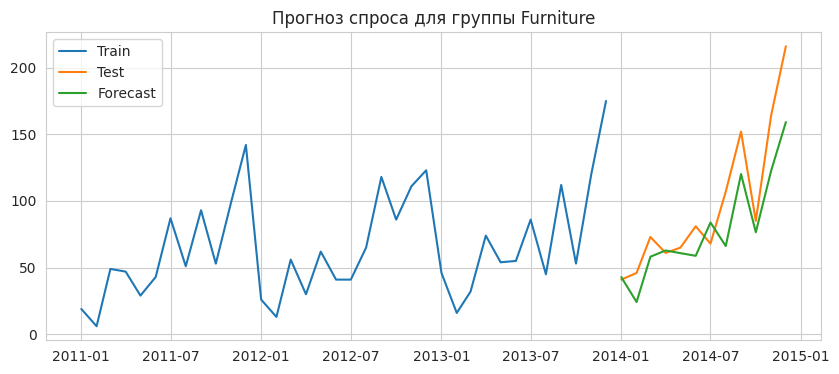

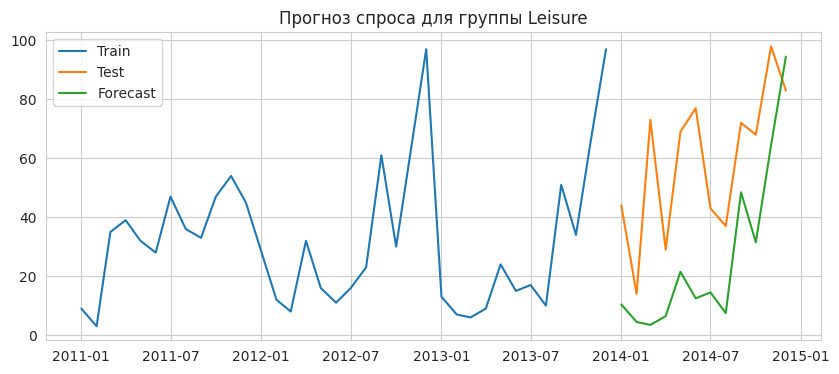

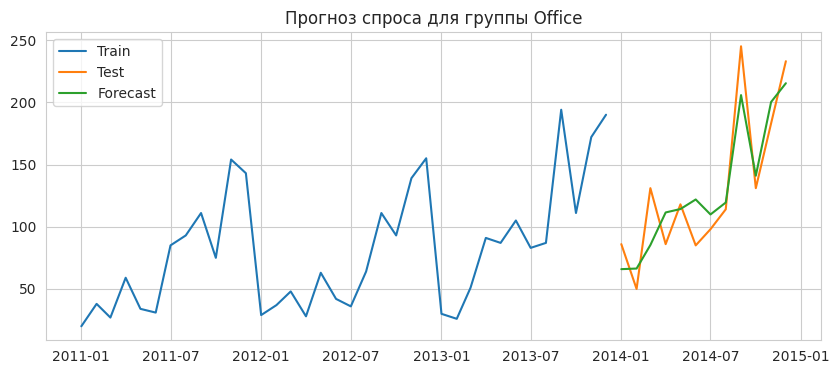

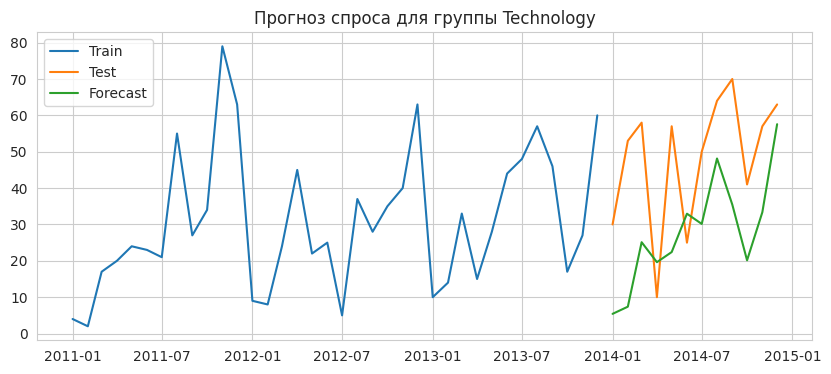

In [ ]:
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt

# Список уникальных групп
groups = monthly_group['ProductGroup'].unique()

# Словарь для хранения прогнозов
forecasts = {}

for group in groups:
    data_new = monthly_group[monthly_group['ProductGroup'] == group].set_index('Order_Month')

    # Проверяем длину ряда (нужно хотя бы пару лет данных)
    if len(data_new) < 24:
        print(f'Слишком мало данных для группы {group}, пропускаем')
        continue

    # Разделим на train и test (последние 12 месяцев — тест)
    train = data_new.iloc[:-12]
    test = data_new.iloc[-12:]

    # Обучаем SARIMA
    model = SARIMAX(train['Quantity'], order=(0,1,1), seasonal_order=(0,1,1,12))
    model_fit = model.fit(disp=False)

    # Прогноз на тест
    forecast_test = model_fit.forecast(steps=12)

    # Сохраняем в словарь
    forecasts[group] = {
        'train': train,
        'test': test,
        'forecast_test': forecast_test,
        'model_fit': model_fit
    }

    plt.figure(figsize=(10,4))
    plt.plot(train.index, train['Quantity'], label='Train')
    plt.plot(test.index, test['Quantity'], label='Test')
    plt.plot(test.index, forecast_test, label='Forecast')
    plt.title(f'Прогноз спроса для группы {group}')
    plt.legend()
    plt.show()



Группа: Furniture — R²: 0.710, MAE: 21.83


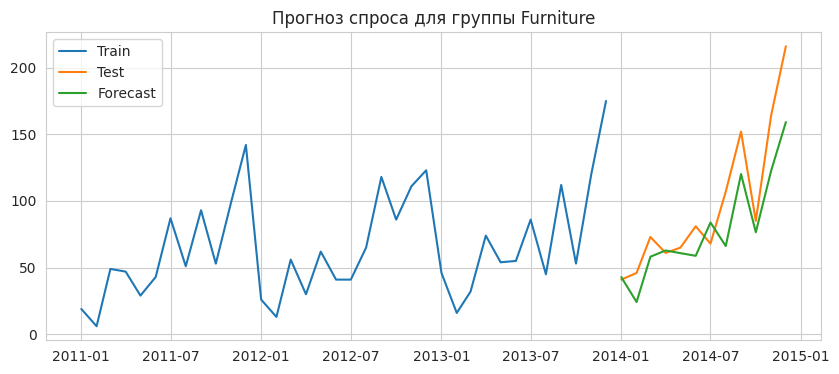

Группа: Leisure — R²: -1.597, MAE: 34.19


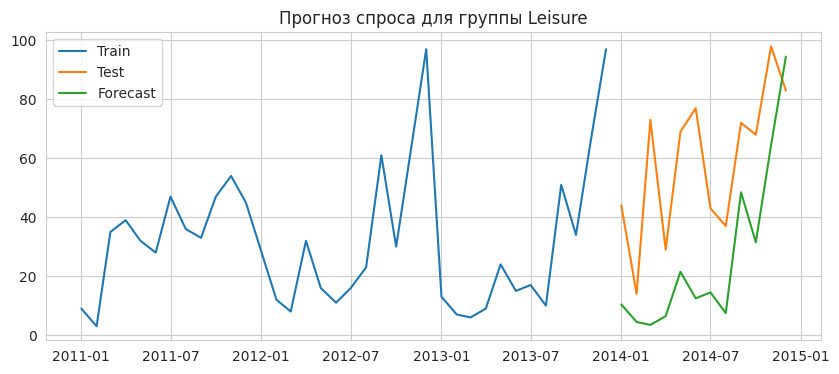

Группа: Office — R²: 0.821, MAE: 20.82


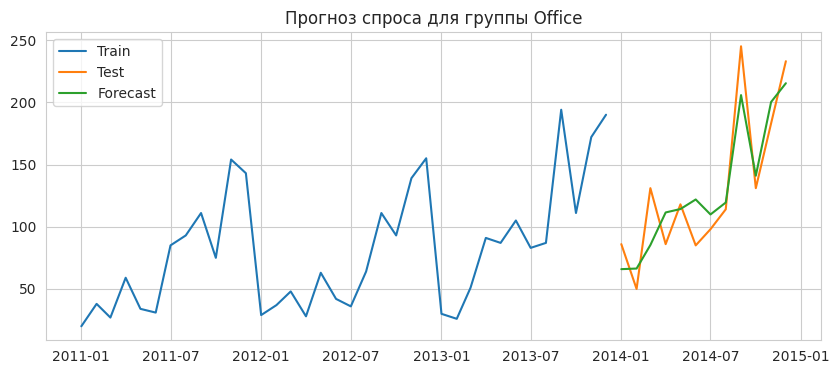

Группа: Technology — R²: -1.216, MAE: 22.95


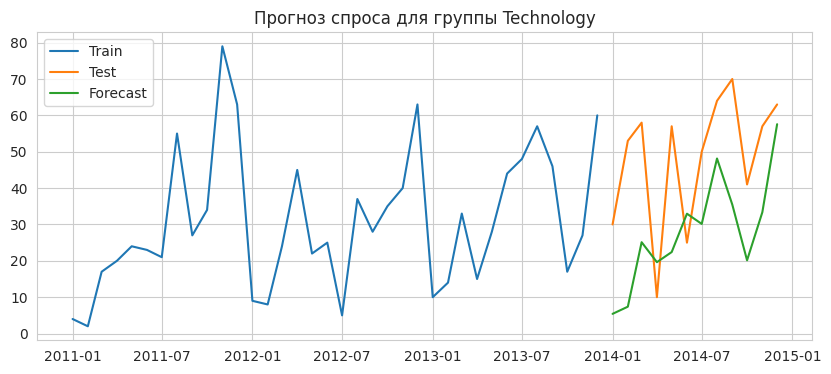

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Список уникальных групп
groups = monthly_group['ProductGroup'].unique()

# Словарь для хранения прогнозов и метрик
forecasts = {}

for group in groups:
    data_new = monthly_group[monthly_group['ProductGroup'] == group].set_index('Order_Month')  # Убедись, что индекс Date

    if len(data_new) < 24:
        print(f'Слишком мало данных для группы {group}, пропускаем')
        continue

    train = data_new.iloc[:-12]
    test = data_new.iloc[-12:]

    model = SARIMAX(train['Quantity'], order=(0,1,1), seasonal_order=(0,1,1,12))
    model_fit = model.fit(disp=False)

    forecast_test = model_fit.forecast(steps=12)

    # Метрики
    r2 = r2_score(test['Quantity'], forecast_test)
    mae = mean_absolute_error(test['Quantity'], forecast_test)

    print(f"Группа: {group} — R²: {r2:.3f}, MAE: {mae:.2f}")

    forecasts[group] = {
        'train': train,
        'test': test,
        'forecast_test': forecast_test,
        'model_fit': model_fit,
        'r2': r2,
        'mae': mae
    }

    plt.figure(figsize=(10,4))
    plt.plot(train.index, train['Quantity'], label='Train')
    plt.plot(test.index, test['Quantity'], label='Test')
    plt.plot(test.index, forecast_test, label='Forecast')
    plt.title(f'Прогноз спроса для группы {group}')
    plt.legend()
    plt.show()


Группа: Furniture, Лучшие параметры: order=(0, 2, 1), seasonal_order=(2, 1, 2, 12), R2=0.837, MAE=15.90


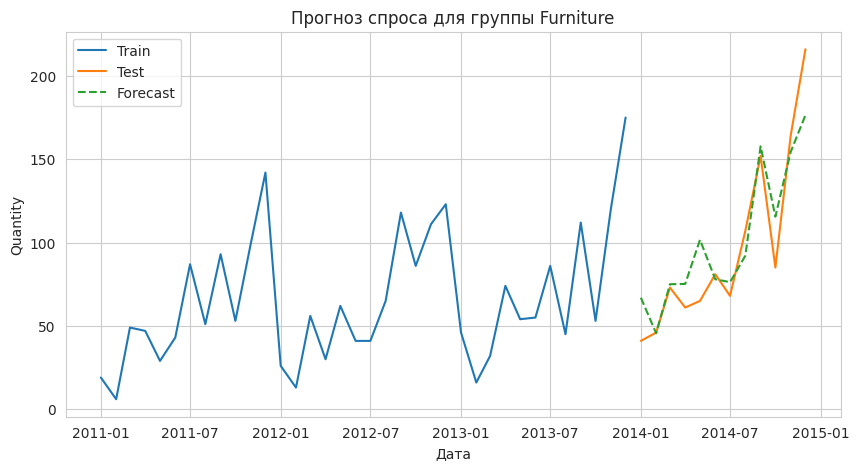

Группа: Leisure, Лучшие параметры: order=(1, 1, 0), seasonal_order=(1, 0, 1, 12), R2=0.445, MAE=14.92


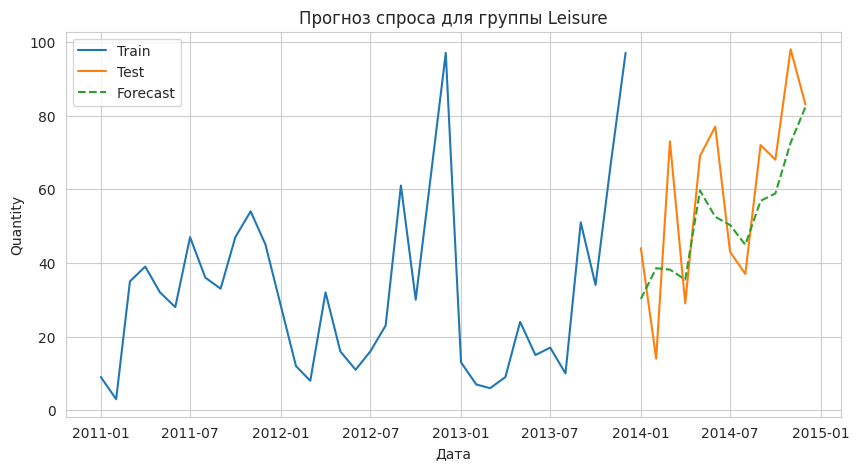

Группа: Office, Лучшие параметры: order=(0, 1, 1), seasonal_order=(0, 1, 2, 12), R2=0.845, MAE=19.28


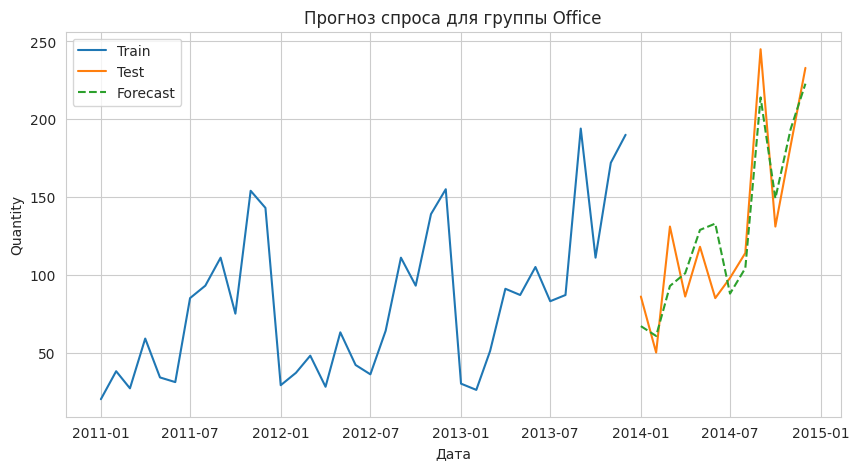

Группа: Technology, Лучшие параметры: order=(0, 2, 1), seasonal_order=(1, 0, 1, 12), R2=0.158, MAE=13.32


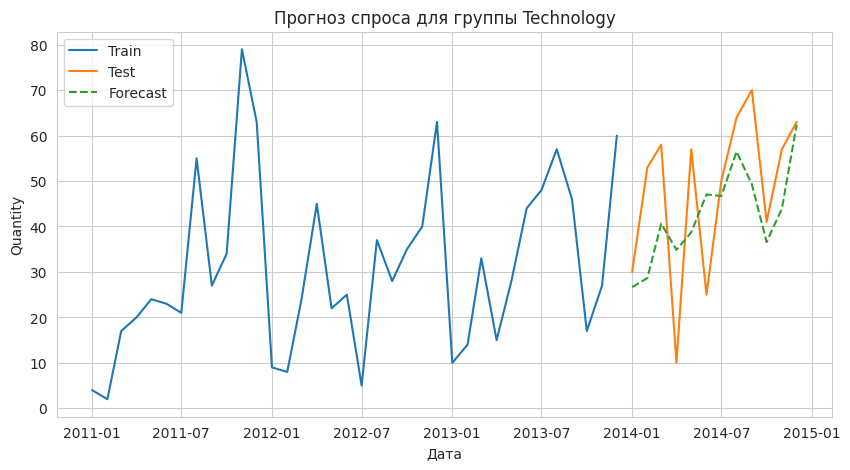

In [ ]:
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error

warnings.filterwarnings("ignore")  # чтобы не засорять вывод
orders = [
    (0, 1, 1), (1, 1, 1), (0, 2, 1), (1, 0, 1),
    (1, 1, 0), (2, 1, 2), (2, 0, 1), (0, 1, 2)
]

seasonal_orders = [
    (0, 1, 1, 12), (1, 1, 1, 12), (0, 2, 1, 12),
    (1, 0, 1, 12), (1, 1, 0, 12), (2, 1, 2, 12),
    (0, 1, 2, 12), (2, 0, 1, 12)
]


best_params_by_group = {}

for group in groups:
    data_new = monthly_group[monthly_group['ProductGroup'] == group].set_index('Order_Month')
    if len(data_new) < 24:
        print(f'Слишком мало данных для группы {group}, пропускаем')
        continue

    train = data_new.iloc[:-12]
    test = data_new.iloc[-12:]

    best_r2 = float('-inf')
    best_mae = float('inf')
    best_order = None
    best_seasonal_order = None
    best_forecast = None

    for order in orders:
        for seasonal_order in seasonal_orders:
            try:
                model = SARIMAX(train['Quantity'], order=order, seasonal_order=seasonal_order)
                model_fit = model.fit(disp=False)
                forecast_test = model_fit.forecast(steps=12)

                r2 = r2_score(test['Quantity'], forecast_test)
                mae = mean_absolute_error(test['Quantity'], forecast_test)

                if r2 > best_r2 or (r2 == best_r2 and mae < best_mae):
                    best_r2 = r2
                    best_mae = mae
                    best_order = order
                    best_seasonal_order = seasonal_order
                    best_forecast = forecast_test
            except Exception:
                continue

    best_params_by_group[group] = {
        'order': best_order,
        'seasonal_order': best_seasonal_order,
        'r2': best_r2,
        'mae': best_mae,
        'forecast': best_forecast
    }

    print(f"Группа: {group}, Лучшие параметры: order={best_order}, seasonal_order={best_seasonal_order}, R2={best_r2:.3f}, MAE={best_mae:.2f}")

    # Визуализация
    plt.figure(figsize=(10, 5))
    plt.plot(train.index, train['Quantity'], label='Train')
    plt.plot(test.index, test['Quantity'], label='Test')
    plt.plot(test.index, best_forecast, label='Forecast', linestyle='--')
    plt.title(f'Прогноз спроса для группы {group}')
    plt.xlabel('Дата')
    plt.ylabel('Quantity')
    plt.legend()
    plt.grid(True)
    plt.show()


In [ ]:
# Создаем колонку с началом месяца (или месяц в нужном формате)
data['YearMonth'] = data['Order Date'].dt.to_period('M').dt.to_timestamp()

# Группируем по месяцу, суммируем Quantity
monthly_quantity = data.groupby('YearMonth')['Quantity'].sum().reset_index()

print(monthly_quantity.head())


   YearMonth  Quantity
0 2011-01-01        52
1 2011-02-01        49
2 2011-03-01       128
3 2011-04-01       165
4 2011-05-01       119


In [ ]:
def group_states(state):
    if state == 'California':
        return 'California'
    elif state == 'Washington':
        return 'Washington'
    else:
        return 'OtherStates'

data['State_Grouped'] = data['State'].apply(group_states)

state_dummies = pd.get_dummies(data['State_Grouped'], prefix='State', drop_first=True)

state_dummies['Order_Month'] = data['Order Date'].dt.to_period('M').dt.to_timestamp()
state_dummies['ProductGroup'] = data['ProductGroup']

state_features = state_dummies.groupby(['Order_Month', 'ProductGroup']).mean().reset_index()

monthly_group = monthly_group.merge(state_features, on=['Order_Month', 'ProductGroup'], how='left')
monthly_group

,Order_Month,ProductGroup,Quantity,State_OtherStates,State_Washington
0,2011-01-01,Furniture,19,0.166667,0.000000
1,2011-01-01,Leisure,9,0.000000,0.000000
2,2011-01-01,Office,20,0.600000,0.000000
3,2011-01-01,Technology,4,1.000000,0.000000
4,2011-02-01,Furniture,6,0.333333,0.000000
...,...,...,...,...,...
186,2014-11-01,Technology,57,0.222222,0.222222
187,2014-12-01,Furniture,216,0.301887,0.188679
188,2014-12-01,Leisure,83,0.200000,0.100000
189,2014-12-01,Office,233,0.187500,0.140625


Группа: Furniture, Лучшие параметры: order=(1, 1, 0), seasonal_order=(0, 1, 1, 12), R2=0.840, MAE=17.36


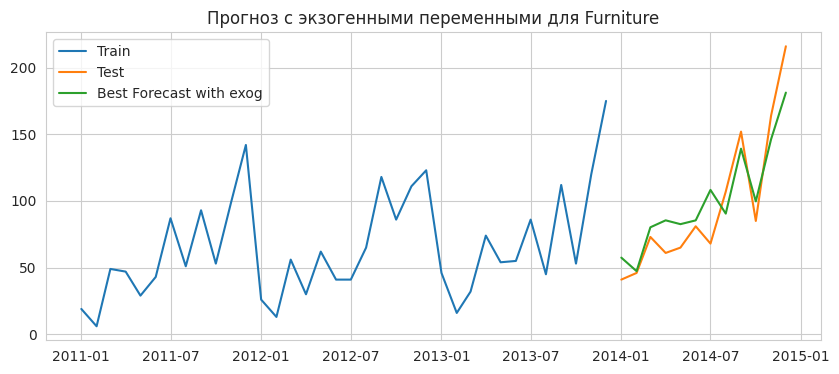

Группа: Leisure, Лучшие параметры: order=(1, 1, 0), seasonal_order=(1, 0, 1, 12), R2=0.550, MAE=13.09


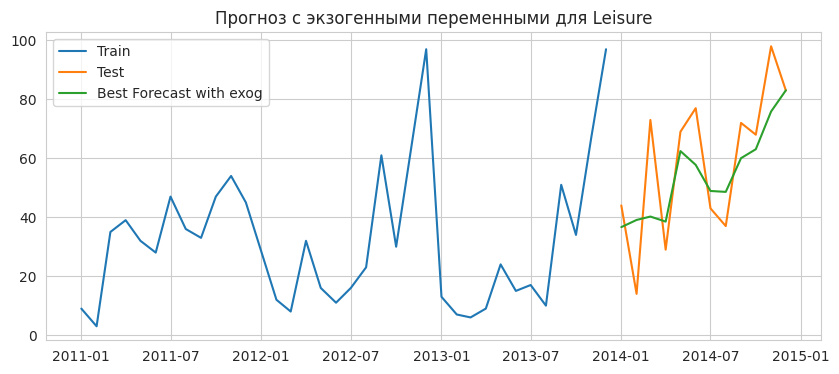

Группа: Office, Лучшие параметры: order=(2, 1, 2), seasonal_order=(0, 1, 2, 12), R2=0.887, MAE=15.86


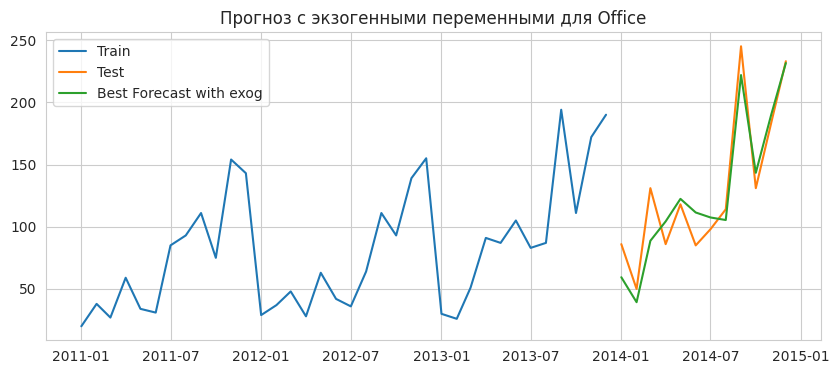

Группа: Technology, Лучшие параметры: order=(0, 2, 1), seasonal_order=(1, 0, 1, 12), R2=0.023, MAE=14.81


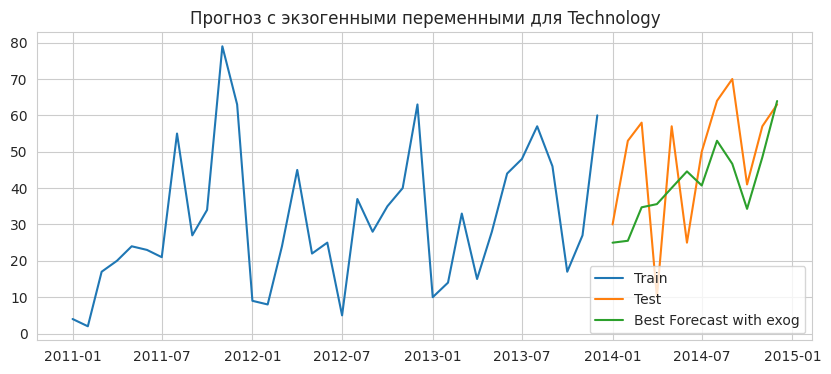

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

orders = [
    (0, 1, 1), (1, 1, 1), (0, 2, 1), (1, 0, 1),
    (1, 1, 0), (2, 1, 2), (2, 0, 1), (0, 1, 2)
]

seasonal_orders = [
    (0, 1, 1, 12), (1, 1, 1, 12), (0, 2, 1, 12),
    (1, 0, 1, 12), (1, 1, 0, 12), (2, 1, 2, 12),
    (0, 1, 2, 12), (2, 0, 1, 12)
]


groups = monthly_group['ProductGroup'].unique()
best_params_by_group = {}

for group in groups:
    data_grp = monthly_group[monthly_group['ProductGroup'] == group].copy()
    data_grp = data_grp.set_index('Order_Month').sort_index()

    y = data_grp['Quantity']
    exog = data_grp[['State_Washington', 'State_OtherStates']]

    if len(y) < 36:
        print(f'Слишком мало данных для группы {group}, пропускаем')
        continue

    y_train, y_test = y[:-12], y[-12:]
    exog_train, exog_test = exog[:-12], exog[-12:]

    best_r2 = float('-inf')
    best_mae = float('inf')
    best_order = None
    best_seasonal_order = None
    best_forecast = None

    for order in orders:
        for seasonal_order in seasonal_orders:
            try:
                model = SARIMAX(y_train, order=order, seasonal_order=seasonal_order, exog=exog_train)
                model_fit = model.fit(disp=False)
                forecast = model_fit.forecast(steps=12, exog=exog_test)

                r2 = r2_score(y_test, forecast)
                mae = mean_absolute_error(y_test, forecast)

                # Выбираем лучшую модель по R2 и MAE
                if r2 > best_r2 or (r2 == best_r2 and mae < best_mae):
                    best_r2 = r2
                    best_mae = mae
                    best_order = order
                    best_seasonal_order = seasonal_order
                    best_forecast = forecast
            except Exception as e:
                continue

    best_params_by_group[group] = {
        'order': best_order,
        'seasonal_order': best_seasonal_order,
        'r2': best_r2,
        'mae': best_mae,
        'forecast': best_forecast
    }

    print(f"Группа: {group}, Лучшие параметры: order={best_order}, seasonal_order={best_seasonal_order}, R2={best_r2:.3f}, MAE={best_mae:.2f}")

    # Визуализация лучшего прогноза
    plt.figure(figsize=(10, 4))
    plt.plot(y_train.index, y_train, label='Train')
    plt.plot(y_test.index, y_test, label='Test')
    plt.plot(y_test.index, best_forecast, label='Best Forecast with exog')
    plt.title(f'Прогноз с экзогенными переменными для {group}')
    plt.legend()
    plt.show()


In [ ]:
data.head()

,Order Date,Category,Sales,Quantity,Profit,Manufacturer,City,State,StateCode,ProductGroup,OrderMonth,OrderWeekday,ShippingDays,OrderYear,YearMonth
0,2013-06-13,Labels,14.620,2,6.8714,others,Los Angeles,California,CA,Office,2013-06,3,4,2013,2013-06
1,2011-06-09,Furnishings,48.860,7,14.1694,eldon,Los Angeles,California,CA,Furniture,2011-06,3,5,2011,2011-06
2,2011-06-09,Art,7.280,4,1.9656,newell,Los Angeles,California,CA,Leisure,2011-06,3,5,2011,2011-06
3,2011-06-09,Phones,907.152,4,90.7152,others,Los Angeles,California,CA,Technology,2011-06,3,5,2011,2011-06
4,2011-06-09,Binders,18.504,3,5.7825,others,Los Angeles,California,CA,Office,2011-06,3,5,2011,2011-06


Prophet (от Facebook)

Что это?
Коробочное решение - простая в использовании модель, которая автоматически учитывает сезонность, праздники и тренды.


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpku0kb9bi/l_iiosss.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpku0kb9bi/uaap0di8.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=8174', 'data', 'file=/tmp/tmpku0kb9bi/l_iiosss.json', 'init=/tmp/tmpku0kb9bi/uaap0di8.json', 'output', 'file=/tmp/tmpku0kb9bi/prophet_modelpop2lwyk/prophet_model-20250629224257.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
22:42:57 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
22:42:59 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


R² на тестовой выборке: -0.269


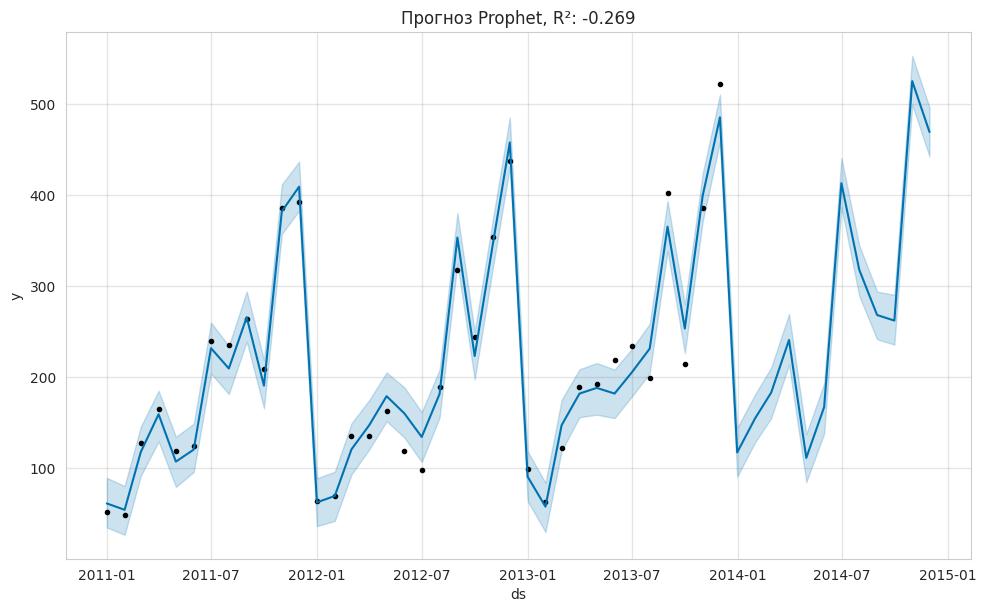

In [ ]:
from prophet import Prophet

# Подготовка
monthly_quantity = monthly_quantity.reset_index()
df_prophet = monthly_quantity.rename(columns={'YearMonth': 'ds', 'Quantity': 'y'})[['ds', 'y']]
df_prophet['ds'] = pd.to_datetime(df_prophet['ds'])

# Делим на train и test
train = df_prophet.iloc[:-12].copy()
test = df_prophet.iloc[-12:].copy()

# Обучаем Prophet
model = Prophet()
model.fit(train)

# Прогнозируем
future = model.make_future_dataframe(periods=12, freq='M')
forecast = model.predict(future)

# Приводим все даты к виду Year-Month
forecast['ds_period'] = forecast['ds'].dt.to_period('M')
test['ds_period'] = test['ds'].dt.to_period('M')

# Объединяем по периоду
merged = pd.merge(
    test,
    forecast[['ds_period', 'yhat']],
    on='ds_period',
    how='inner'
)

# Оценка
r2 = r2_score(merged['y'], merged['yhat'])
print(f'R² на тестовой выборке: {r2:.3f}')

# График
model.plot(forecast)
plt.title(f'Прогноз Prophet, R²: {r2:.3f}')
plt.show()
